# Full Inference: Analysis

Two-layer student model with hidden neurons, missing units, weight noise, and learned FF mapping.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import toml
import torch
import zarr
from scipy.spatial.distance import cosine as cosine_dist

from connectome_snns.utils.reproducibility import load_experiment_config
from connectome_snns.analysis import run_two_layer_inference, ensure_test_inputs
from connectome_snns.analysis import run_two_layer_tracked_inference
from connectome_snns.configs.conductance_based import RecurrentLayerConfig, FeedforwardLayerConfig
from connectome_snns.visualization import (
    use_project_style,
    plot_spike_trains,
    plot_firing_rate_scatter,
    plot_sf_bar_chart,
    EXCITATORY_COLOR,
    INHIBITORY_COLOR,
    TEACHER_COLOR,
    STUDENT_COLOR,
)
from connectome_snns.visualization.scaling_factors import SF_PATHWAYS
from connectome_snns.visualization.dashboards import create_activity_dashboard

use_project_style()


In [2]:
# Load experiment config
config = load_experiment_config("experiment.toml")
RESULTS_DIR = config["output_dir"]
PARAMS_FILE = config["parameters_file"]

# Device for inference
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load training metrics and parameters
metrics = pd.read_csv(RESULTS_DIR / "training_metrics.csv")
params = toml.load(RESULTS_DIR / "parameters.toml")
chunk_size = params["simulation"]["chunk_size"]

# Compute chunks per data epoch for x-axis scaling
zarr_root = zarr.open_group(RESULTS_DIR / "inputs" / "spike_data.zarr", mode="r")
total_timesteps = zarr_root["output_spikes"].shape[1]
CHUNKS_PER_EPOCH = total_timesteps // chunk_size


# Load neuron classification
nc = np.load(RESULTS_DIR / "targets" / "neuron_classification.npz")
visible_indices = nc["visible_indices"]
unobserved_indices = nc["unobserved_indices"]
n_visible = len(visible_indices)
n_hidden = len(unobserved_indices)

# Load target scaling factors
target_sf = np.load(RESULTS_DIR / "targets" / "target_scaling_factors.npz")[
    "feedforward_scaling_factors"
]

print(f"Results: {RESULTS_DIR}")
print(f"Neurons: {n_visible} visible, {n_hidden} hidden")
print(f"Chunks per data epoch: {CHUNKS_PER_EPOCH}")

Results: /tachyon/groups/scratch/gzenke/bedfrory/dp-simulations/full-inference/surrgrad-10
Neurons: 2250 visible, 2250 hidden
Chunks per data epoch: 150


In [3]:
# Generate (or load cached) teacher test activity: same network as training,
# but batch_size=1 and seed+10 for an unseen rollout. Cached as a zarr in the run dir.
TEST_ZARR_PATH = ensure_test_inputs(RESULTS_DIR, device=DEVICE)

# Inference window: burn-in from training params, analysis = rest of test data.
_test_root = zarr.open_group(TEST_ZARR_PATH, mode="r")
_test_total_chunks = _test_root["input_spikes"].shape[1] // chunk_size
_test_dt = float(_test_root.attrs["dt"])
N_BURNIN_CHUNKS = int(params["training"]["burn_in_chunks"])
N_ANALYSIS_CHUNKS = _test_total_chunks - N_BURNIN_CHUNKS
print(
    f"Test inference: {N_BURNIN_CHUNKS} burnin + {N_ANALYSIS_CHUNKS} analysis chunks "
    f"({N_BURNIN_CHUNKS * chunk_size * _test_dt / 1000:.1f}s + "
    f"{N_ANALYSIS_CHUNKS * chunk_size * _test_dt / 1000:.1f}s)"
)

Test inference: 50 burnin + 100 analysis chunks (5.0s + 10.0s)


## Scaling Factors

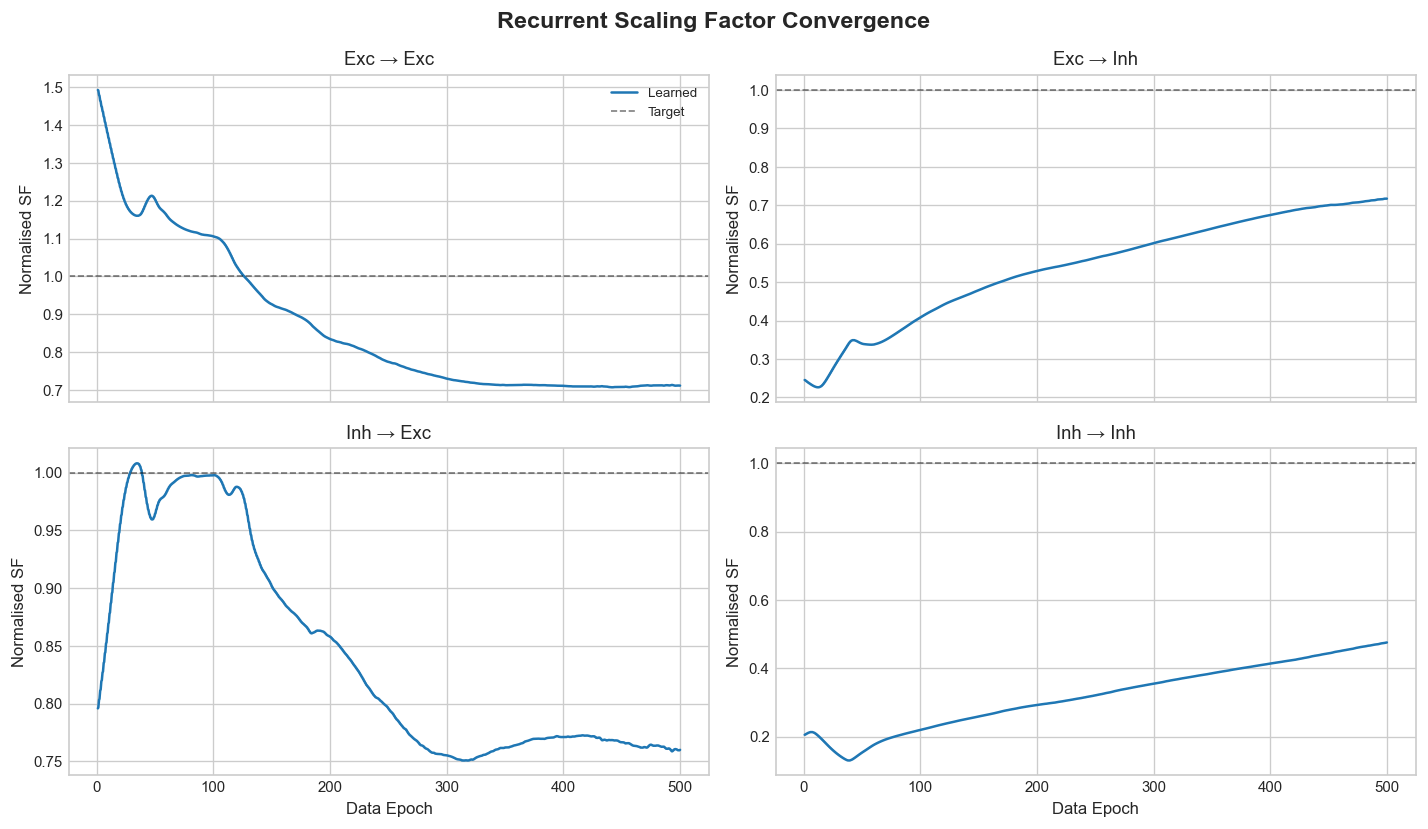

In [4]:
# Scaling factor trajectories (recurrent only; FF SFs are absorbed into weights)
smooth_window = 10

rec_pathways = [p for p in SF_PATHWAYS if not p[0].startswith("mitral_")]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

for idx, (key, title) in enumerate(rec_pathways):
    ax = axes.flat[idx]
    col_val = f"scaling_factors/{key}_value"
    col_tgt = f"scaling_factors/{key}_target"

    if col_val in metrics.columns:
        x = metrics["epoch"] / CHUNKS_PER_EPOCH
        ax.plot(
            x,
            metrics[col_val].rolling(smooth_window).mean(),
            linewidth=1.5,
            label="Learned",
        )
    if col_tgt in metrics.columns:
        ax.axhline(
            y=metrics[col_tgt].iloc[0],
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.5,
            label="Target",
        )

    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Normalised SF")
    if idx >= 2:
        ax.set_xlabel("Data Epoch")
    if idx == 0:
        ax.legend(loc="best", fontsize=8)

plt.suptitle("Recurrent Scaling Factor Convergence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

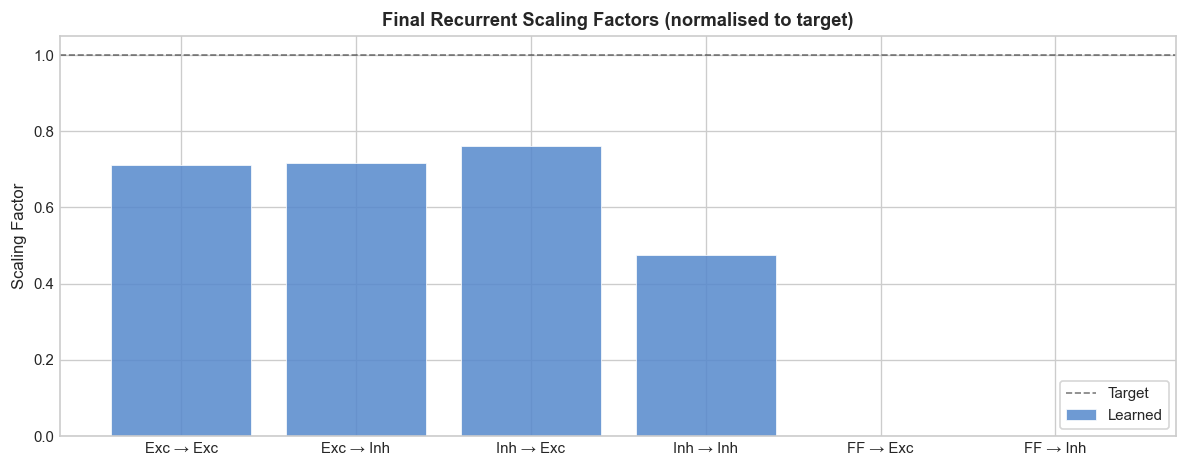

In [5]:
# Final scaling factor bar chart (recurrent only)
final = metrics.iloc[-1]
rec_pathways = [p for p in SF_PATHWAYS if not p[0].startswith("mitral_")]
sf_final = {
    k: float(final[f"scaling_factors/{k}_value"])
    for k, _ in rec_pathways
    if f"scaling_factors/{k}_value" in metrics.columns
}

plot_sf_bar_chart(
    {"Learned": sf_final},
    condition_labels=["Learned"],
    condition_colors=[STUDENT_COLOR],
    figsize=(10, 4),
    title="Final Recurrent Scaling Factors (normalised to target)",
)
plt.show()

## Loss Trajectory

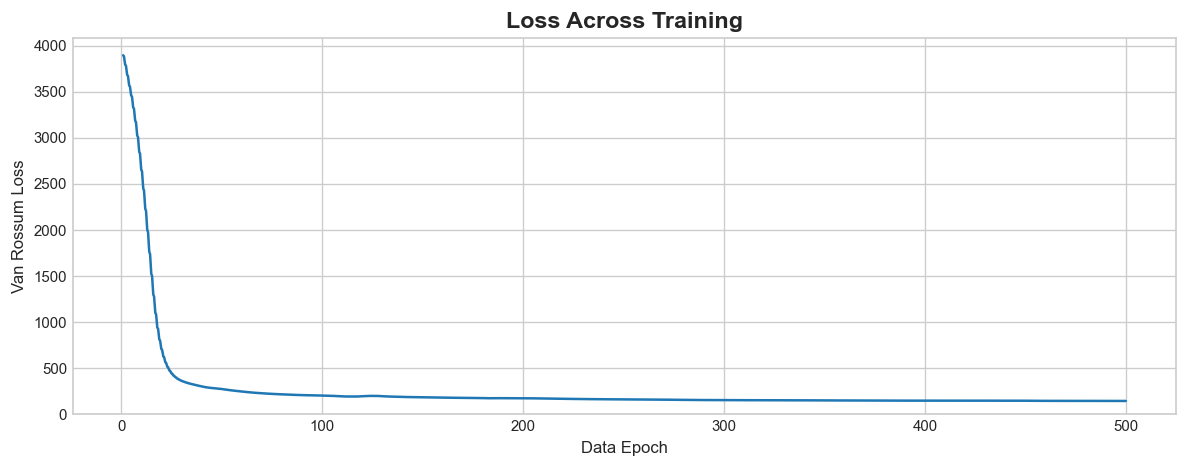

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

loss_col = "van_rossum_loss" if "van_rossum_loss" in metrics.columns else "total_loss"
x = metrics["epoch"] / CHUNKS_PER_EPOCH
smoothed = metrics[loss_col].rolling(smooth_window).mean()
ax.plot(x, smoothed, linewidth=1.5)
ax.set_xlabel("Data Epoch")
ax.set_ylabel("Van Rossum Loss")
ax.set_title("Loss Across Training", fontsize=14, fontweight="bold")
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## Firing Rates (Training Logs)

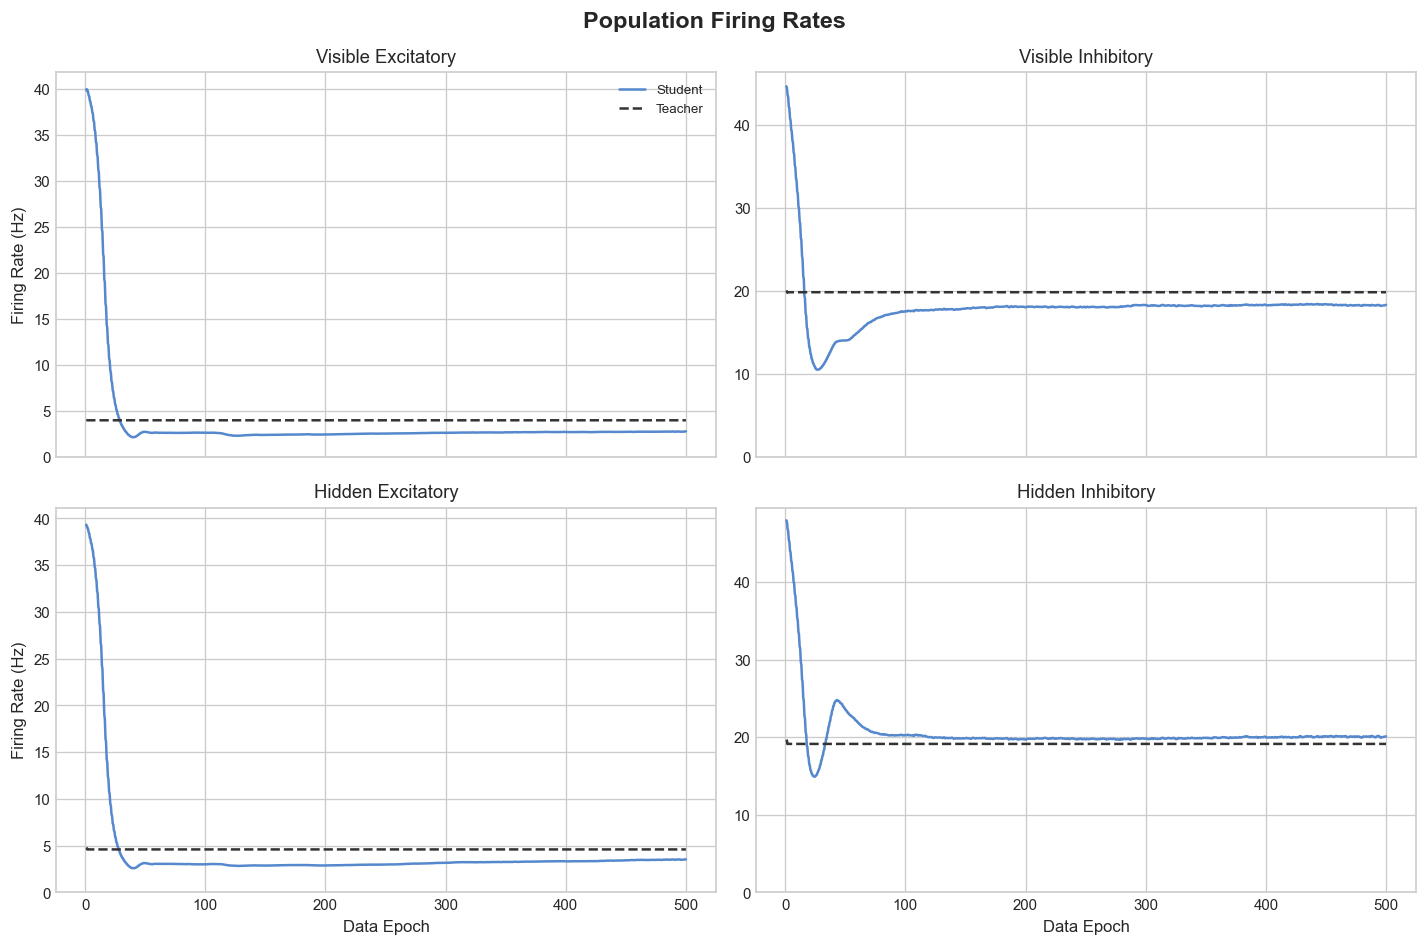

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

fr_grid = [
    (0, 0, "visible", "excitatory", "Visible Excitatory"),
    (0, 1, "visible", "inhibitory", "Visible Inhibitory"),
    (1, 0, "hidden", "excitatory", "Hidden Excitatory"),
    (1, 1, "hidden", "inhibitory", "Hidden Inhibitory"),
]

for row, col, visibility, cell_type, title in fr_grid:
    ax = axes[row, col]
    student_col = f"firing_rate/student_{visibility}_{cell_type}_mean"
    teacher_col = f"firing_rate/teacher_{visibility}_{cell_type}_mean"

    x = metrics["epoch"] / CHUNKS_PER_EPOCH

    if student_col in metrics.columns:
        ax.plot(
            x,
            metrics[student_col].rolling(smooth_window).mean(),
            color=STUDENT_COLOR,
            linewidth=1.5,
            label="Student",
        )
    if teacher_col in metrics.columns:
        ax.plot(
            x,
            metrics[teacher_col].rolling(smooth_window).mean(),
            color=TEACHER_COLOR,
            linewidth=1.5,
            linestyle="--",
            label="Teacher",
        )

    ax.set_title(title)
    ax.set_ylim(0, None)
    if row == 1:
        ax.set_xlabel("Data Epoch")
    if col == 0:
        ax.set_ylabel("Firing Rate (Hz)")
    if row == 0 and col == 0:
        ax.legend(fontsize=8)

plt.suptitle("Population Firing Rates", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## FF Weight Analysis

In [8]:
# Load FF weights and effective scaling factors
ns = np.load(RESULTS_DIR / "inputs" / "network_structure.npz")
true_ff_weights = ns["feedforward_weights"]  # (n_ff_inputs, n_neurons_original)
n_ff_inputs = true_ff_weights.shape[0]

# Handle structural masking
missing_frac = float(nc["missing_unit_fraction"])
if missing_frac > 0:
    structural_hidden = nc.get("structural_hidden_indices", np.array([], dtype=int))
    structural_visible = np.setdiff1d(
        np.arange(nc["n_neurons_original"]), structural_hidden
    )
    true_ff_reduced = true_ff_weights[:, structural_visible]
    student_cell_type_indices = ns["cell_type_indices"][structural_visible]
else:
    true_ff_reduced = true_ff_weights
    student_cell_type_indices = ns["cell_type_indices"]

# Student initial: reconstruct full (n_ff, n_neurons) from per-layer initial state
l1_init = np.load(RESULTS_DIR / "initial_state" / "layer1.npz")
l2_init = np.load(RESULTS_DIR / "initial_state" / "layer2.npz")
n_neurons = l1_init["ff_weights"].shape[1] + l2_init["ff_weights"].shape[1]
init_ff = np.zeros((n_ff_inputs, n_neurons), dtype=np.float32)
init_ff[:, unobserved_indices] = l1_init["ff_weights"][:n_ff_inputs, :]
init_ff[:, visible_indices] = l2_init["ff_weights"][:n_ff_inputs, :]

# --- Load checkpoint (for SFs and final FF weights) ---
ckpt_path = RESULTS_DIR / "checkpoints" / "checkpoint_best.pt"
if not ckpt_path.exists():
    ckpt_path = RESULTS_DIR / "checkpoints" / "checkpoint_latest.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
sd = ckpt["model_state_dict"]

# Cell-type names for projection state-dict keys (src__tgt).
_rec_cfg_tmp = RecurrentLayerConfig(**params["recurrent"])
_cell_type_names = list(_rec_cfg_tmp.cell_types.names)
n_cell_types = len(_cell_type_names)

# Recurrent scaling factor matrix: reconstruct (n_rec_ct, n_rec_ct) from
# per-pair ScalingFactorProjection.log_sf parameters on layer1.rec_projections.
eff_sf_rec = np.ones((n_cell_types, n_cell_types), dtype=np.float32)
for src_id, src_name in enumerate(_cell_type_names):
    for tgt_id, tgt_name in enumerate(_cell_type_names):
        key = f"layer1.rec_projections.{src_name}__{tgt_name}.log_sf"
        if key in sd:
            eff_sf_rec[src_id, tgt_id] = float(torch.exp(sd[key]).item())

print(f"Recurrent SF:\n{eff_sf_rec}")

# --- Student final FF weights ---
# Priority: weight snapshots > checkpoint (shared low-rank U_ct @ V_ct per output type)
snapshot_dir = RESULTS_DIR / "weight_snapshots"
snapshots_exist = snapshot_dir.exists() and any(snapshot_dir.glob("epoch_*.npz"))

if snapshots_exist:
    snapshot_files = sorted(snapshot_dir.glob("epoch_*.npz"))
    final_snapshot = np.load(snapshot_files[-1])
    learned_ff_log = final_snapshot["ff_weights"]  # (n_ff_inputs, n_neurons) log-space
    final_ff = np.exp(learned_ff_log)
    print(f"\nLoaded final FF weights from {snapshot_files[-1].name}")
    print(f"  {len(snapshot_files)} weight snapshots available")
else:
    learned_ff_log = None

    # Reconstruct from shared per-cell-type U_ct @ V_ct in the checkpoint.
    final_ff = np.zeros((n_ff_inputs, n_neurons), dtype=np.float32)
    found_any = False
    for ct_idx in range(n_cell_types):
        U_key = f"_shared_ff_U.{ct_idx}"
        V_key = f"_shared_ff_V.{ct_idx}"
        if U_key in sd and V_key in sd:
            U = sd[U_key]
            V = sd[V_key]
            ct_neurons = np.flatnonzero(student_cell_type_indices == ct_idx)
            final_ff[:, ct_neurons] = torch.exp(U @ V).numpy()
            found_any = True
    if found_any:
        print("\nReconstructed final FF weights from checkpoint U_ct @ V_ct")
    else:
        final_ff = None
        print("\nNo FF weights found in checkpoint.")

Recurrent SF:
[[0.47411877 2.8793504 ]
 [0.9649446  2.2680683 ]]

Loaded final FF weights from epoch_075000.npz
  500 weight snapshots available


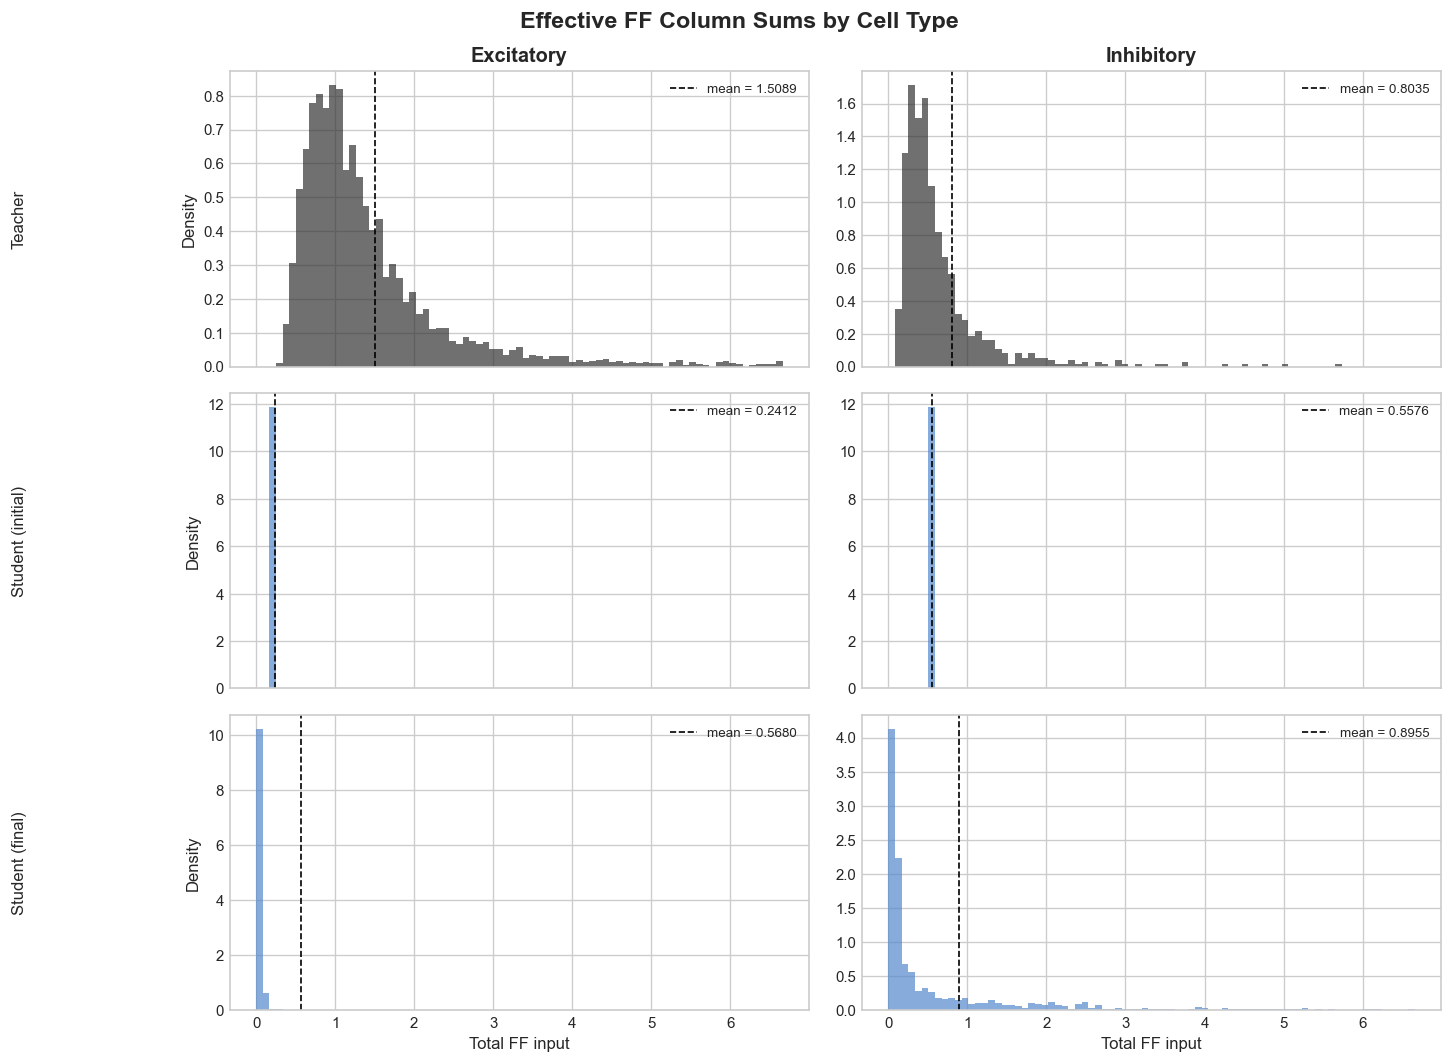

In [9]:
# FF weight column sums: teacher, initial, final.
# Split by excitatory / inhibitory output neurons.
# Student columns = sum_i mitral-weight[i, j] directly — FF SFs are absorbed
# into the learned low-rank weights.

rec_cfg = RecurrentLayerConfig(**params["recurrent"])
cell_type_names = rec_cfg.cell_types.names

# Cell type indices for the reduced neuron set
if missing_frac > 0:
    cell_type_indices = ns["cell_type_indices"][structural_visible]
else:
    cell_type_indices = ns["cell_type_indices"]

# Teacher column sums (sf_teacher = 1.0 from config)
teacher_col_sums = true_ff_reduced.sum(axis=0)

# Student initial column sums (model SF = 1.0 at start, perturbation already in weights)
init_col_sums = init_ff.sum(axis=0)

# Final column sums from learned weights.
if final_ff is not None:
    final_col_sums = final_ff.sum(axis=0)
else:
    final_col_sums = None

# Build row definitions
rows = [
    ("Teacher", teacher_col_sums, TEACHER_COLOR),
    ("Student (initial)", init_col_sums, STUDENT_COLOR),
]
if final_col_sums is not None:
    rows.append(("Student (final)", final_col_sums, STUDENT_COLOR))

n_rows = len(rows)
n_types = len(cell_type_names)
fig, axes = plt.subplots(
    n_rows, n_types, figsize=(6 * n_types, 3 * n_rows), sharex=True, sharey=False
)

# Shared bins from teacher
teacher_nz = teacher_col_sums[teacher_col_sums > 0]
bins = np.linspace(0, np.percentile(teacher_nz, 99), 80)

for row_idx, (title, col_sums, color) in enumerate(rows):
    for type_idx, type_name in enumerate(cell_type_names):
        ax = axes[row_idx, type_idx]
        mask = cell_type_indices == type_idx
        vals = col_sums[mask]
        vals_nz = vals[vals > 0]

        ax.hist(vals_nz, bins=bins, alpha=0.7, density=True, color=color)
        ax.axvline(
            vals_nz.mean(),
            color="black",
            linestyle="--",
            linewidth=1,
            label=f"mean = {vals_nz.mean():.4f}",
        )
        ax.legend(fontsize=8)

        if type_idx == 0:
            ax.set_ylabel("Density")
        if row_idx == 0:
            ax.set_title(type_name.title(), fontsize=12, fontweight="bold")
        if row_idx == n_rows - 1:
            ax.set_xlabel("Total FF input")

        # Row label on left margin
        if type_idx == 0:
            ax.annotate(
                title,
                xy=(-0.35, 0.5),
                xycoords="axes fraction",
                ha="right",
                va="center",
                fontsize=10,
                rotation=90,
            )

plt.suptitle("Effective FF Column Sums by Cell Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
# Diagnostic: where do zero-FF-column neurons come from?
#
# The constant initialisation uses constant_val = mean(teacher_col_sums_of_type) / n_ff_inputs.
# If teacher has no mitral input to a cell type at all, the whole type is
# initialised at exactly zero and training has no reason to lift it. Check:

eps = 1e-6

print("=== (1) Per-cell-type init constants ===")
for t_idx, t_name in enumerate(cell_type_names):
    tm = cell_type_indices == t_idx
    tcs = true_ff_reduced[:, tm].sum(axis=0)
    mean_ff = tcs.mean()
    n_teacher_zero = int((tcs == 0).sum())
    print(
        f"  {t_name:12s}  teacher mean col-sum = {mean_ff:.4g}  "
        f"constant-init val = {mean_ff / n_ff_inputs:.4g}  "
        f"teacher zero cols = {n_teacher_zero}/{int(tm.sum())}"
    )

print("\n=== (2) Zero-column counts: teacher vs student (final) ===")
if final_col_sums is not None:
    for t_idx, t_name in enumerate(cell_type_names):
        tm = cell_type_indices == t_idx
        t_zero = int((teacher_col_sums[tm] < eps).sum())
        s_zero = int((final_col_sums[tm] < eps).sum())
        print(
            f"  {t_name:12s}  teacher zero = {t_zero:5d}  "
            f"student zero = {s_zero:5d}  of {int(tm.sum())}"
        )

    print("\n=== (3) Training-floor artifact vs genuine zero ===")
    floor = n_ff_inputs * 1e-12 * 10  # ~10x the snapshot-clip floor sum
    n_exact_zero = int((final_col_sums == 0).sum())
    n_at_floor = int((final_col_sums < floor).sum())
    nz = final_col_sums[final_col_sums > 0]
    print(f"  exactly 0: {n_exact_zero}")
    print(f"  below floor ({floor:.2g}): {n_at_floor}")
    if nz.size:
        print(f"  smallest nonzero final col sum: {nz.min():.4g}")
else:
    print("  (no final_ff available)")


=== (1) Per-cell-type init constants ===
  excitatory    teacher mean col-sum = 1.509  constant-init val = 0.001006  teacher zero cols = 0/3605
  inhibitory    teacher mean col-sum = 0.8035  constant-init val = 0.0005357  teacher zero cols = 0/895

=== (2) Zero-column counts: teacher vs student (final) ===
  excitatory    teacher zero =     0  student zero =     0  of 3605
  inhibitory    teacher zero =     0  student zero =     0  of 895

=== (3) Training-floor artifact vs genuine zero ===
  exactly 0: 0
  below floor (1.5e-08): 0
  smallest nonzero final col sum: 0.0006259


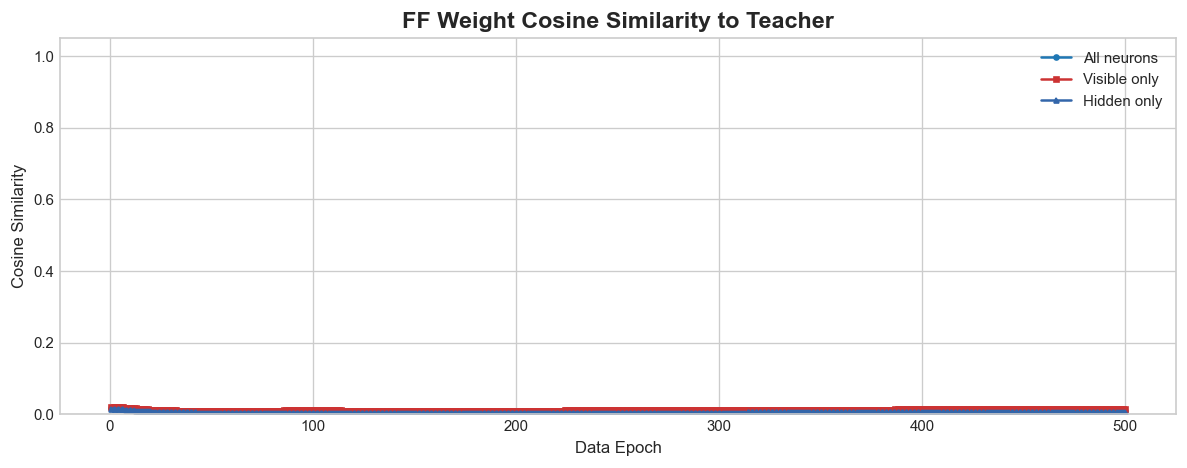

In [11]:
# Cosine similarity evolution during Phase 2
if snapshots_exist:
    epochs = []
    cos_sims = []
    cos_sims_hidden = []
    cos_sims_visible = []

    # True FF as flat reference vectors
    true_hidden = true_ff_reduced[:, unobserved_indices].ravel()
    true_visible = true_ff_reduced[:, visible_indices].ravel()
    true_all = true_ff_reduced.ravel()

    for sf in snapshot_files:
        snap = np.load(sf)
        epoch = int(snap["epoch"])
        w = np.exp(snap["ff_weights"])  # (n_ff_inputs, n_neurons)

        epochs.append(epoch / CHUNKS_PER_EPOCH)
        cos_sims.append(1.0 - cosine_dist(true_all, w.ravel()))
        cos_sims_hidden.append(
            1.0 - cosine_dist(true_hidden, w[:, unobserved_indices].ravel())
        )
        cos_sims_visible.append(
            1.0 - cosine_dist(true_visible, w[:, visible_indices].ravel())
        )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, cos_sims, "o-", linewidth=1.5, markersize=3, label="All neurons")
    ax.plot(
        epochs,
        cos_sims_visible,
        "s-",
        linewidth=1.5,
        markersize=3,
        color=EXCITATORY_COLOR,
        label="Visible only",
    )
    ax.plot(
        epochs,
        cos_sims_hidden,
        "^-",
        linewidth=1.5,
        markersize=3,
        color=INHIBITORY_COLOR,
        label="Hidden only",
    )
    ax.set_xlabel("Data Epoch")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(
        "FF Weight Cosine Similarity to Teacher", fontsize=14, fontweight="bold"
    )
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
else:
    print("No weight snapshots available. Re-run experiment to generate them.")

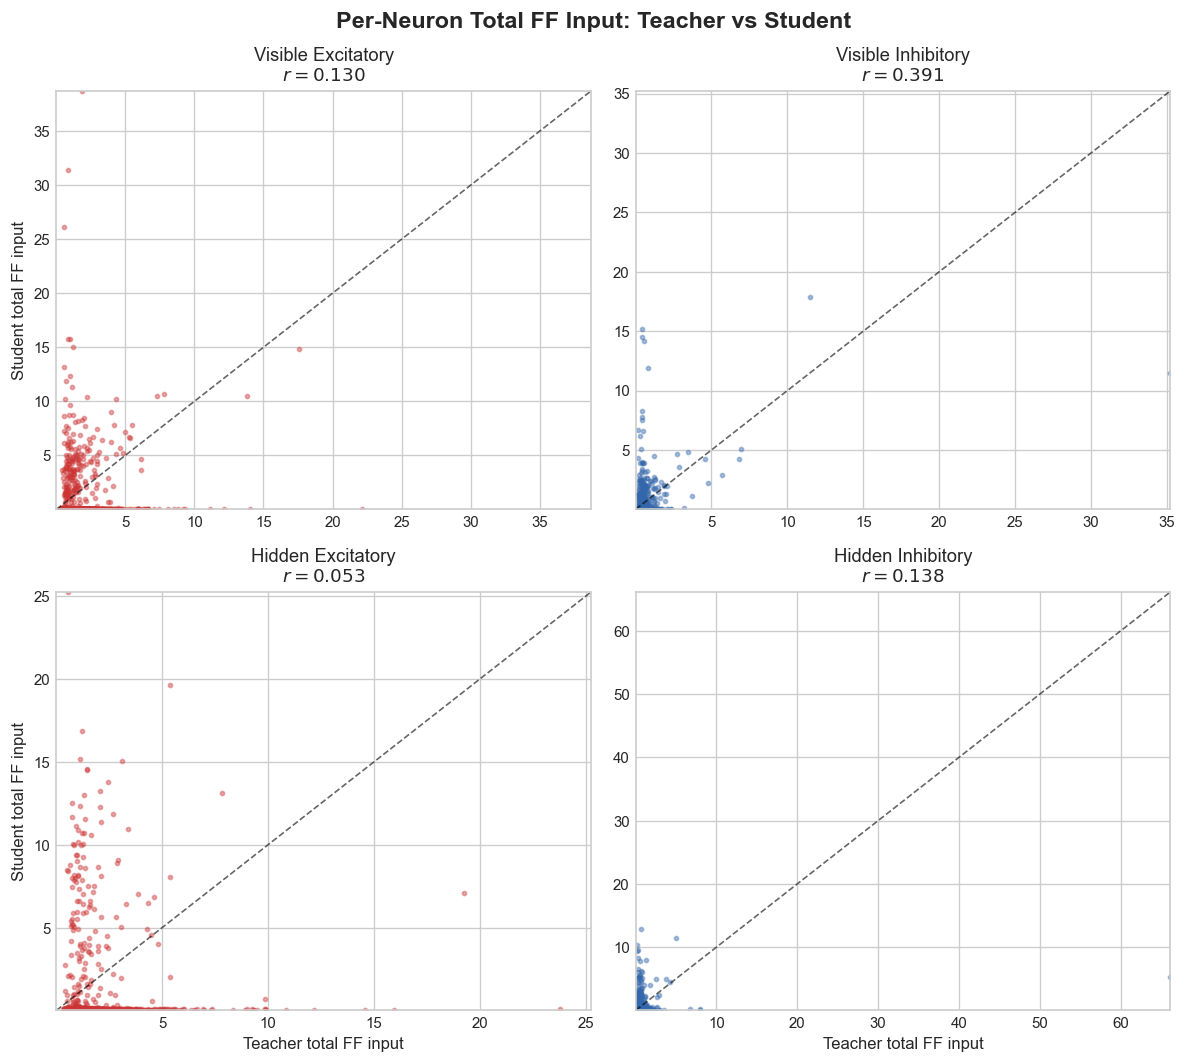

In [12]:
# Teacher vs student per-neuron TOTAL FF input (column sums), split by
# cell type x visibility. Pearson r shown at the top of each subplot.
# (Matches the column-sum scatter in the learn-ff-connectivity notebook.)
if final_ff is not None:
    from connectome_snns.analysis import r_squared

    groups = []
    for t_idx, t_name in enumerate(cell_type_names):
        type_mask_global = cell_type_indices == t_idx
        for vis_label, vis_idx in [
            ("Visible", visible_indices),
            ("Hidden", unobserved_indices),
        ]:
            sub = np.intersect1d(vis_idx, np.where(type_mask_global)[0])
            teacher_total = true_ff_reduced[:, sub].sum(
                axis=0
            )  # per-neuron total FF input
            student_total = final_ff[:, sub].sum(axis=0)
            groups.append(
                (f"{vis_label} {t_name.title()}", teacher_total, student_total)
            )

    n_types = len(cell_type_names)
    fig, axes = plt.subplots(2, n_types, figsize=(5 * n_types, 9), squeeze=False)

    for ax_idx, (title, t_tot, s_tot) in enumerate(groups):
        row = ax_idx % 2
        col = ax_idx // 2
        ax = axes[row, col]

        r2 = r_squared(t_tot, s_tot)

        color = EXCITATORY_COLOR if "Excitatory" in title else INHIBITORY_COLOR
        ax.scatter(t_tot, s_tot, s=6, alpha=0.4, color=color, rasterized=True)

        lims = [
            min(t_tot.min(), s_tot.min()),
            max(t_tot.max(), s_tot.max()),
        ]
        ax.plot(lims, lims, "k--", linewidth=1, alpha=0.6)
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        ax.set_title(f"{title}\n$R^2 = {r2:.3f}$", fontsize=11)
        if row == 1:
            ax.set_xlabel("Teacher total FF input")
        if col == 0:
            ax.set_ylabel("Student total FF input")

    plt.suptitle(
        "Per-Neuron Total FF Input: Teacher vs Student", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()
else:
    print("No final FF weights available.")

## Inference

In [13]:
# Recurrent SF already loaded in the FF weight analysis cell above.
print(f"Recurrent SF:\n{eff_sf_rec}")

Recurrent SF:
[[0.47411877 2.8793504 ]
 [0.9649446  2.2680683 ]]


In [14]:
# Run two-layer inference on the held-out test rollout
cache_path = RESULTS_DIR / "inference_cache_test.npz"

# Use learned FF weights if available (log-space for run_two_layer_inference)
if learned_ff_log is not None:
    ff_weights_for_inference = learned_ff_log
elif final_ff is not None:
    ff_weights_for_inference = np.log(np.maximum(final_ff, 1e-12))
else:
    ff_weights_for_inference = None

# Delete stale cache if chunk counts changed
if cache_path.exists():
    cached = np.load(cache_path)
    expected_ts = N_ANALYSIS_CHUNKS * chunk_size
    actual_key = (
        "teacher_visible_spikes" if "teacher_visible_spikes" in cached else None
    )
    if actual_key and cached[actual_key].shape[0] != expected_ts:
        print(
            f"Stale cache ({cached[actual_key].shape[0]} vs {expected_ts} timesteps), deleting."
        )
        cache_path.unlink()

# FF scaling factors: mitral rows are 1.0 (SFs absorbed into learned weights),
# rerouted recurrent rows use the learned recurrent SFs (matching
# _SharedScalingFactors from training).
_n_ff_ct = len(FeedforwardLayerConfig(**params['feedforward']).cell_types.names)
sf_ff_for_inference = np.vstack(
    [
        np.ones((_n_ff_ct, eff_sf_rec.shape[1])),
        eff_sf_rec,
    ]
)

data = run_two_layer_inference(
    params_file=RESULTS_DIR / "parameters.toml",
    run_dir=RESULTS_DIR,
    zarr_subpath=str(TEST_ZARR_PATH),
    scaling_factors=eff_sf_rec,
    scaling_factors_FF=sf_ff_for_inference,
    ff_weights=ff_weights_for_inference,
    n_burnin_chunks=N_BURNIN_CHUNKS,
    n_analysis_chunks=N_ANALYSIS_CHUNKS,
    cache_path=cache_path,
    device=DEVICE,
)

In [15]:
# Compute per-neuron firing rates
dt = data["dt"]
duration_s = data["teacher_visible_spikes"].shape[0] * dt / 1000.0

teacher_vis_rates = data["teacher_visible_spikes"].sum(axis=0) / duration_s
student_vis_rates = data["student_visible_spikes"].sum(axis=0) / duration_s
teacher_hid_rates = data["teacher_hidden_spikes"].sum(axis=0) / duration_s
student_hid_rates = data["student_hidden_spikes"].sum(axis=0) / duration_s

vis_ct = data["visible_cell_types"]
hid_ct = data["hidden_cell_types"]

print(f"Inference duration: {duration_s:.1f}s")
print(f"Visible neurons: {len(vis_ct)} | Hidden neurons: {len(hid_ct)}")

Inference duration: 10.0s
Visible neurons: 2250 | Hidden neurons: 2250


### Feedforward vs Recurrent Excitatory Drive

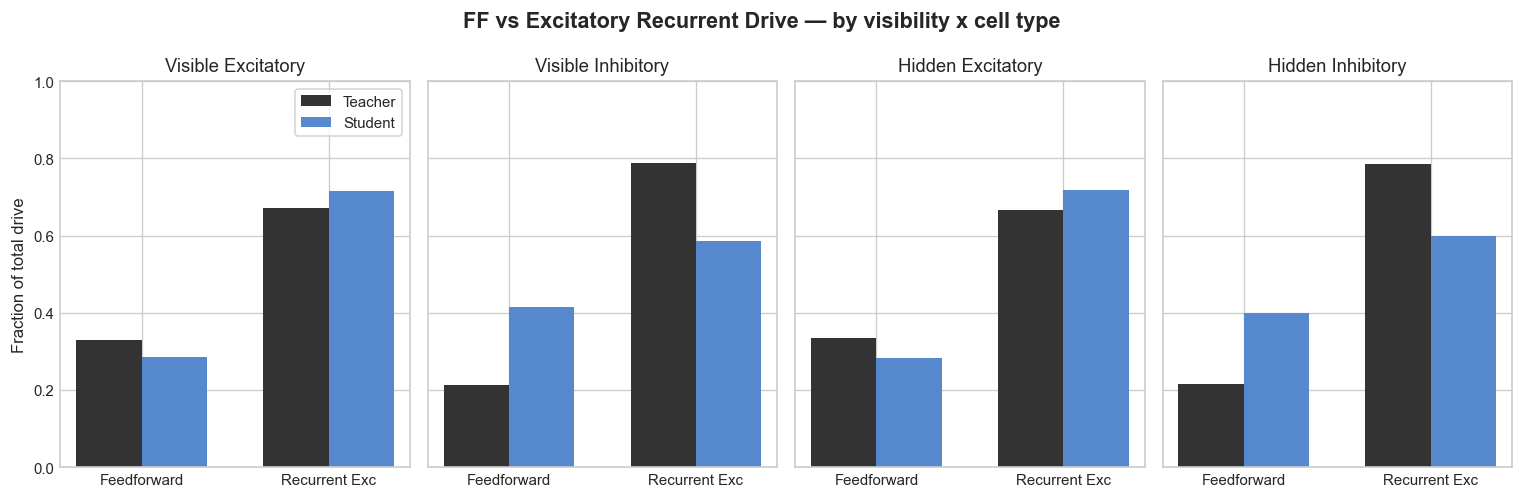

In [16]:
# Per-target FF vs recurrent drive, grouped by visibility x cell type.
#
# Drive into target neuron j:
#   FF drive[j]  = sum_i mitral_count[i] * W_mitral[i, j]
#   Rec drive[j] = sum_k neuron_count[k] * W_rec[k, j]
#
# Both teacher and student use spike counts from the same inference window.
# Teacher uses teacher weights; student uses effective weights (initial * learned SFs).

# --- Spike counts from inference window (same duration for both) ---
# Teacher neuron counts
teacher_neuron_counts = np.zeros(n_neurons, dtype=np.int64)
teacher_neuron_counts[visible_indices] = (
    data["teacher_visible_spikes"].sum(axis=0).astype(np.int64)
)
teacher_neuron_counts[unobserved_indices] = (
    data["teacher_hidden_spikes"].sum(axis=0).astype(np.int64)
)

# Student neuron counts
student_neuron_counts = np.zeros(n_neurons, dtype=np.int64)
student_neuron_counts[visible_indices] = (
    data["student_visible_spikes"].sum(axis=0).astype(np.int64)
)
student_neuron_counts[unobserved_indices] = (
    data["student_hidden_spikes"].sum(axis=0).astype(np.int64)
)

# Mitral counts from the inference window
zarr_root = zarr.open_group(TEST_ZARR_PATH, mode="r")
zarr_dt = float(zarr_root.attrs["dt"])
burnin_ts = N_BURNIN_CHUNKS * chunk_size
analysis_ts = N_ANALYSIS_CHUNKS * chunk_size
mitral_counts = (
    zarr_root["input_spikes"][0, burnin_ts : burnin_ts + analysis_ts, :]
    .sum(axis=0)
    .astype(np.int64)
)

n_ff_teacher = zarr_root["input_spikes"].shape[2]
n_neurons_orig = zarr_root["output_spikes"].shape[2]

# Reduce teacher weights to the structural-visible neuron set.
if missing_frac > 0:
    teacher_rec_w = ns["recurrent_weights"][
        np.ix_(structural_visible, structural_visible)
    ]
else:
    teacher_rec_w = ns["recurrent_weights"]

assert n_ff_teacher == n_ff_inputs, (
    f"This cell assumes n_ff_teacher ({n_ff_teacher}) == n_ff_inputs ({n_ff_inputs}); "
    "latent-input runs need a separate version."
)

# Only excitatory recurrent drive (matching learn-ff-connectivity convention).
exc_type_idx = cell_type_names.index("excitatory")
exc_source_mask = cell_type_indices == exc_type_idx

# --- Teacher drive ---
teacher_ff_drive = mitral_counts @ true_ff_reduced
teacher_rec_drive = (
    teacher_neuron_counts[exc_source_mask] @ teacher_rec_w[exc_source_mask, :]
)

# --- Student recurrent matrix from initial state + learned SFs ---
n_hid = len(unobserved_indices)
n_vis = len(visible_indices)
student_rec = np.zeros((n_neurons, n_neurons), dtype=np.float32)

student_rec[np.ix_(unobserved_indices, unobserved_indices)] = l1_init["rec_weights"]
student_rec[np.ix_(visible_indices, unobserved_indices)] = l1_init["ff_weights"][
    n_ff_inputs:, :
]
l2_non_mitral = l2_init["ff_weights"][n_ff_inputs:, :]
student_rec[np.ix_(unobserved_indices, visible_indices)] = l2_non_mitral[:n_hid, :]
student_rec[np.ix_(visible_indices, visible_indices)] = l2_non_mitral[n_hid:, :]

for src_type in range(len(cell_type_names)):
    src_idx = np.where(cell_type_indices == src_type)[0]
    for tgt_type in range(len(cell_type_names)):
        tgt_idx = np.where(cell_type_indices == tgt_type)[0]
        student_rec[np.ix_(src_idx, tgt_idx)] *= eff_sf_rec[src_type, tgt_type]

# --- Student drive ---
student_ff_drive = mitral_counts @ final_ff
student_rec_drive = (
    student_neuron_counts[exc_source_mask] @ student_rec[exc_source_mask, :]
)

# --- Group by visibility x cell type ---
vis_mask_full = np.zeros(n_neurons, dtype=bool)
vis_mask_full[visible_indices] = True

groups = []
for vis_label, target_mask in [("Visible", vis_mask_full), ("Hidden", ~vis_mask_full)]:
    for t_idx, t_name in enumerate(cell_type_names):
        m = target_mask & (cell_type_indices == t_idx)
        if not m.any():
            continue
        groups.append(
            (
                f"{vis_label} {t_name.title()}",
                {
                    "teacher_ff": float(teacher_ff_drive[m].mean()),
                    "teacher_rec": float(teacher_rec_drive[m].mean()),
                    "student_ff": float(student_ff_drive[m].mean()),
                    "student_rec": float(student_rec_drive[m].mean()),
                },
            )
        )

# --- Plot ---
fig, axes = plt.subplots(1, len(groups), figsize=(3.2 * len(groups), 4.2), sharey=True)
if len(groups) == 1:
    axes = [axes]

x = np.arange(2)
width = 0.35
for ax, (title, d) in zip(axes, groups):
    t_tot = d["teacher_ff"] + d["teacher_rec"] + 1e-12
    s_tot = d["student_ff"] + d["student_rec"] + 1e-12
    teacher_fracs = [d["teacher_ff"] / t_tot, d["teacher_rec"] / t_tot]
    student_fracs = [d["student_ff"] / s_tot, d["student_rec"] / s_tot]

    ax.bar(x - width / 2, teacher_fracs, width, color=TEACHER_COLOR, label="Teacher")
    ax.bar(x + width / 2, student_fracs, width, color=STUDENT_COLOR, label="Student")
    ax.set_xticks(x)
    ax.set_xticklabels(["Feedforward", "Recurrent Exc"])
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Fraction of total drive")
axes[0].legend(frameon=True, fontsize=9, loc="upper right")
plt.suptitle(
    "FF vs Excitatory Recurrent Drive — by visibility x cell type",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### Per-Neuron Firing Rate Scatter

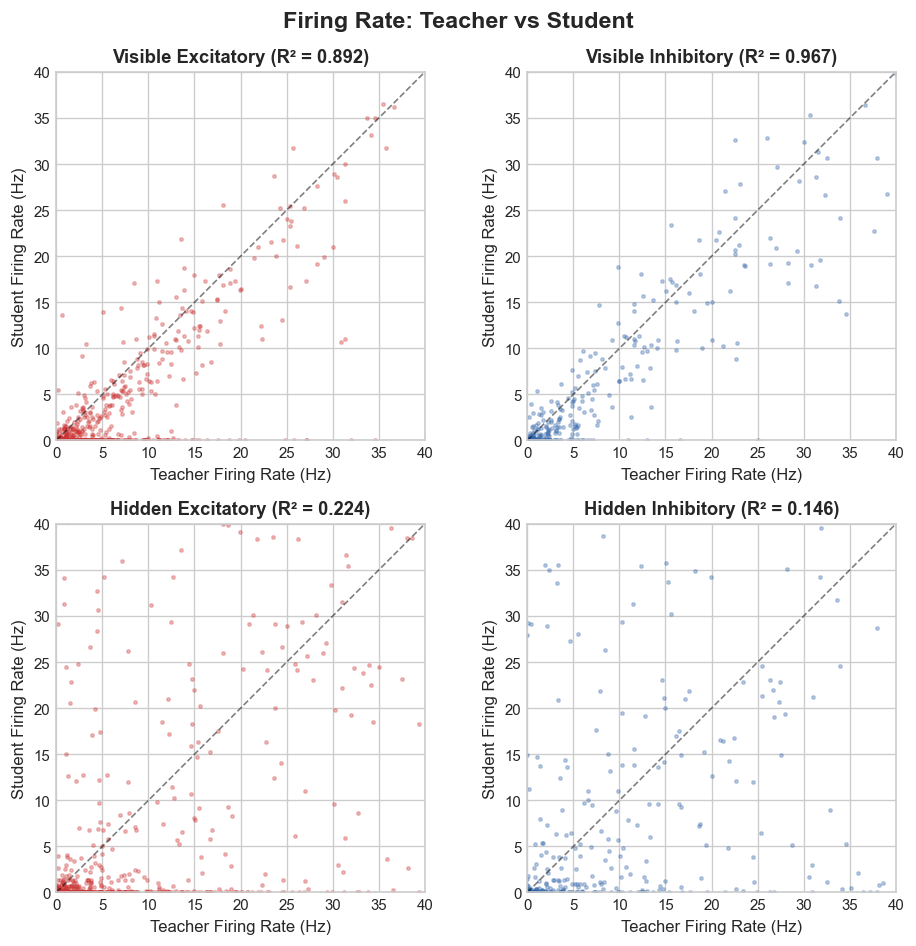

In [17]:
GROUP_NAMES = [
    "Visible Excitatory",
    "Visible Inhibitory",
    "Hidden Excitatory",
    "Hidden Inhibitory",
]
GROUP_COLORS = [
    EXCITATORY_COLOR,
    INHIBITORY_COLOR,
    EXCITATORY_COLOR,
    INHIBITORY_COLOR,
]

teacher = np.concatenate([teacher_vis_rates, teacher_hid_rates])
student = np.concatenate([student_vis_rates, student_hid_rates])
group = np.concatenate([vis_ct, hid_ct + 2])

MAX_RATE = min(40.0, np.percentile(teacher, 99) * 1.2)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
plot_firing_rate_scatter(
    teacher,
    student,
    group,
    split_panels=True,
    axes=[axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]],
    cell_type_names=GROUP_NAMES,
    cell_type_colors=GROUP_COLORS,
    max_rate=MAX_RATE,
    marker_size=4,
    alpha=0.3,
)
fig.suptitle("Firing Rate: Teacher vs Student", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

### Spike Raster Comparisons

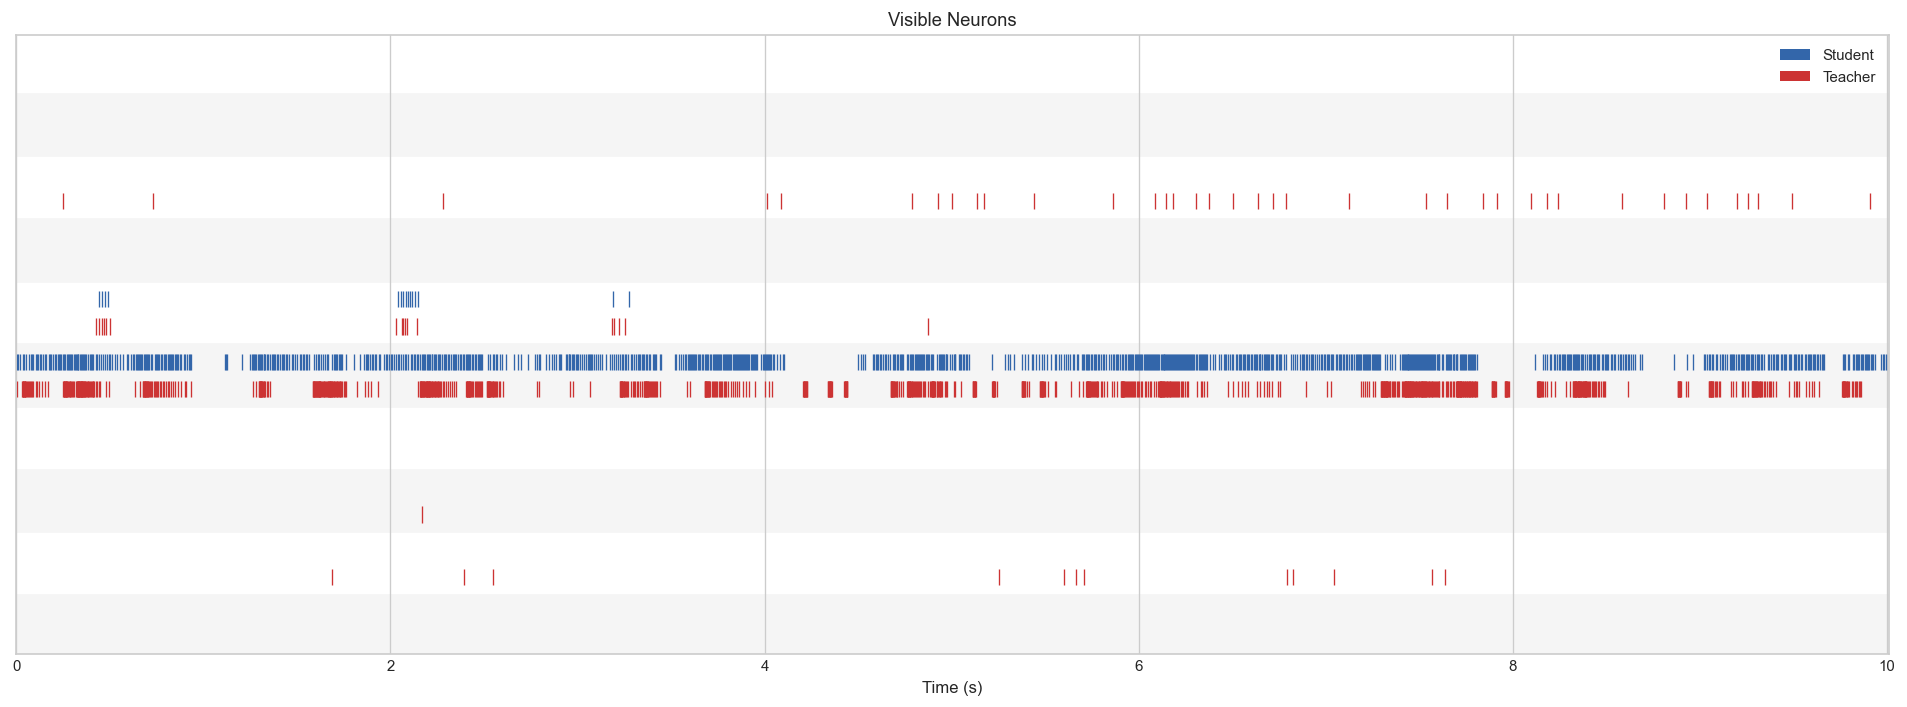

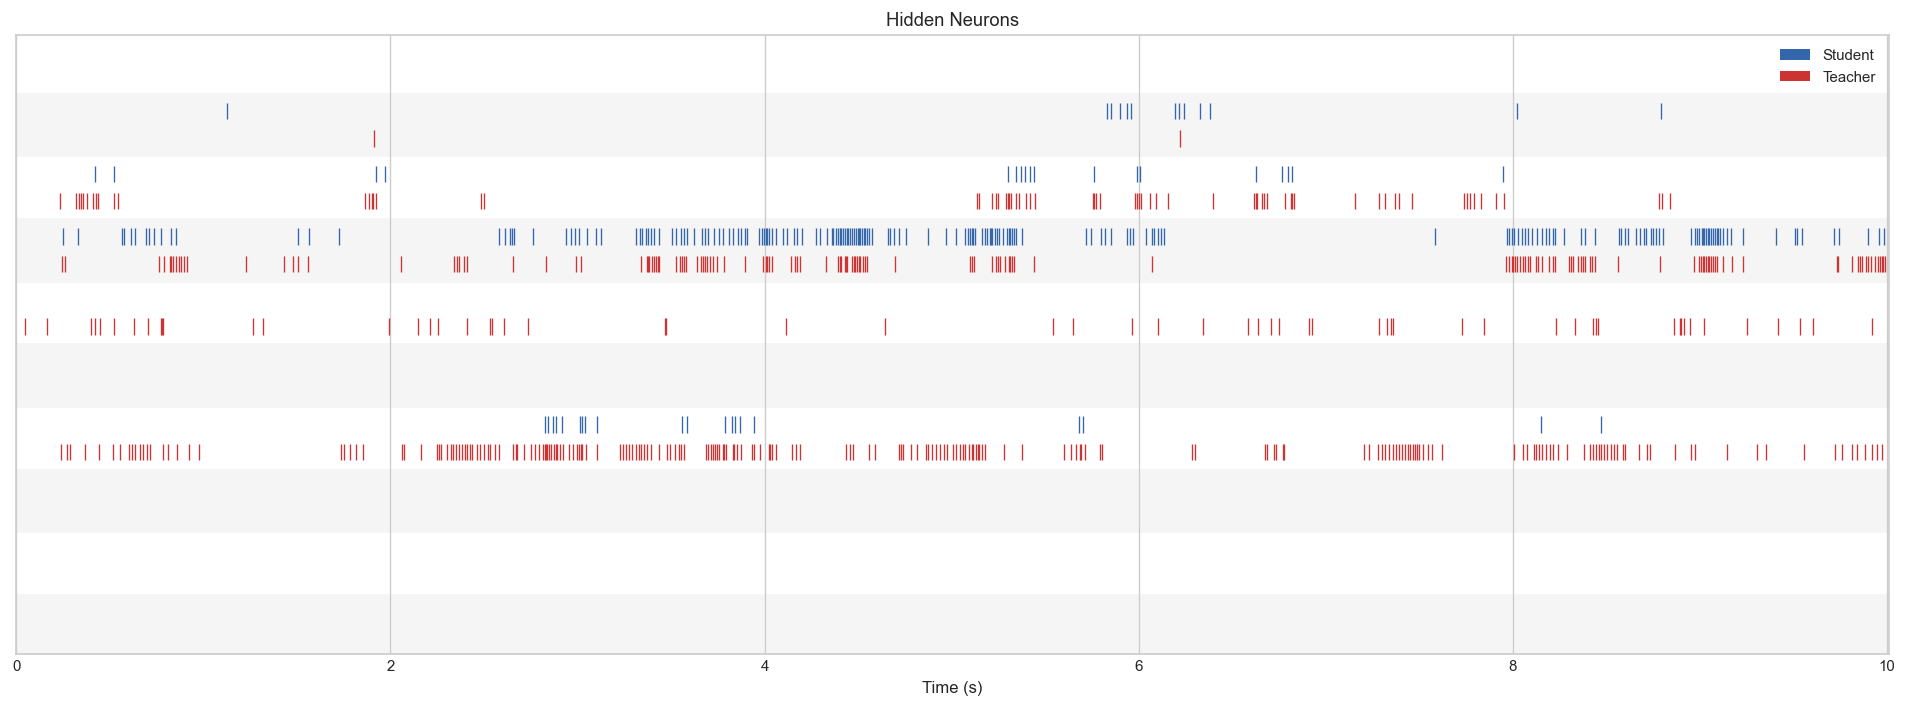

In [18]:
def interleave_spike_trains(teacher, student):
    """Interleave teacher/student spikes for side-by-side raster."""
    n_neurons = teacher.shape[1]
    interleaved = np.zeros((teacher.shape[0], 2 * n_neurons))
    for i in range(n_neurons):
        interleaved[:, 2 * i] = teacher[:, i]
        interleaved[:, 2 * i + 1] = student[:, i]
    ct = np.tile([0, 1], n_neurons)
    return interleaved[np.newaxis, :, :], ct


N_NEURONS_SHOW = 10
rng = np.random.RandomState(42)
show_vis = np.sort(rng.choice(n_visible, min(N_NEURONS_SHOW, n_visible), replace=False))
show_hid = np.sort(rng.choice(n_hidden, min(N_NEURONS_SHOW, n_hidden), replace=False))

for vis_type, cols, t_spikes, s_spikes in [
    (
        "Visible",
        show_vis,
        data["teacher_visible_spikes"],
        data["student_visible_spikes"],
    ),
    ("Hidden", show_hid, data["teacher_hidden_spikes"], data["student_hidden_spikes"]),
]:
    interleaved, ct_idx = interleave_spike_trains(t_spikes[:, cols], s_spikes[:, cols])

    fig = plot_spike_trains(
        spikes=interleaved,
        dt=dt,
        cell_type_indices=ct_idx,
        cell_type_names=["Teacher", "Student"],
        n_neurons_plot=2 * len(cols),
        n_compared=2,
        fraction=1.0,
        random_seed=None,
        title=f"{vis_type} Neurons",
        figsize=(16, 6),
    )
    plt.show()

### Membrane Potential Statistics

In [19]:
# Run inference with voltage recording for both teacher and student.
# Teacher uses target SFs (to correct perturbation in initial_state weights).
teacher_voltage_cache = RESULTS_DIR / "voltage_cache_teacher_test.npz"
student_voltage_cache = RESULTS_DIR / "voltage_cache_student_test.npz"

# Teacher: target SFs to correct perturbation, true FF weights
n_ff_ct = 1  # mitral only
sf_teacher_rec = target_sf[n_ff_ct:, :]  # rec rows of FF target = rec target
sf_teacher_ff = target_sf.copy()
true_ff_log = np.log(np.maximum(true_ff_reduced, 1e-12))

data_teacher = run_two_layer_inference(
    params_file=RESULTS_DIR / "parameters.toml",
    run_dir=RESULTS_DIR,
    zarr_subpath=str(TEST_ZARR_PATH),
    scaling_factors=sf_teacher_rec,
    scaling_factors_FF=sf_teacher_ff,
    ff_weights=true_ff_log,
    n_burnin_chunks=N_BURNIN_CHUNKS,
    n_analysis_chunks=N_ANALYSIS_CHUNKS,
    cache_path=teacher_voltage_cache,
    device=DEVICE,
    desc="teacher voltage inference",
    record_voltage_stats=True,
)

# Student: learned SFs and FF weights (same as main inference)
data_student = run_two_layer_inference(
    params_file=RESULTS_DIR / "parameters.toml",
    run_dir=RESULTS_DIR,
    zarr_subpath=str(TEST_ZARR_PATH),
    scaling_factors=eff_sf_rec,
    scaling_factors_FF=sf_ff_for_inference,
    ff_weights=ff_weights_for_inference,
    n_burnin_chunks=N_BURNIN_CHUNKS,
    n_analysis_chunks=N_ANALYSIS_CHUNKS,
    cache_path=student_voltage_cache,
    device=DEVICE,
    desc="student voltage inference",
    record_voltage_stats=True,
)

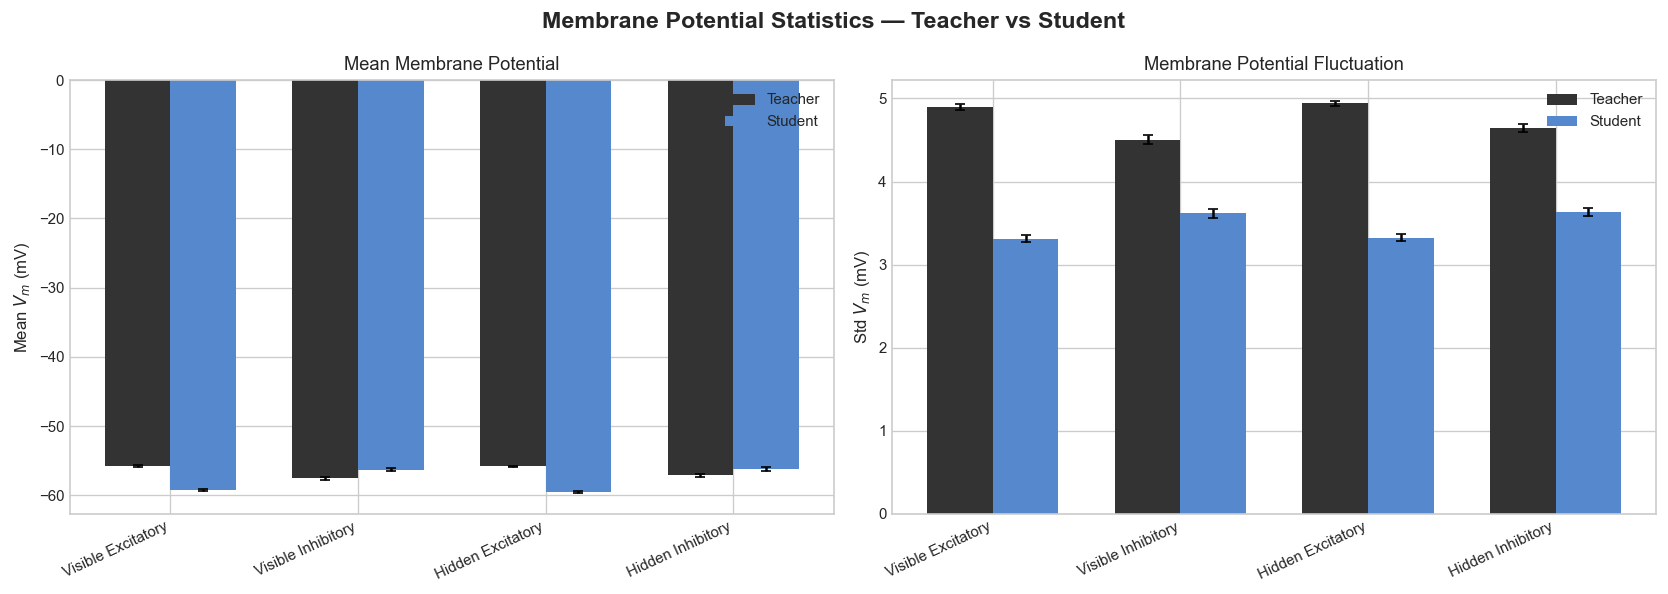

In [20]:
# Bar chart: membrane potential mean and fluctuation (std), teacher vs student,
# split by visibility x cell type.
groups_v = []
for vis_label, v_mean_t, v_std_t, v_mean_s, v_std_s, ct in [
    (
        "Visible",
        data_teacher["visible_v_mean"],
        data_teacher["visible_v_std"],
        data_student["visible_v_mean"],
        data_student["visible_v_std"],
        vis_ct,
    ),
    (
        "Hidden",
        data_teacher["hidden_v_mean"],
        data_teacher["hidden_v_std"],
        data_student["hidden_v_mean"],
        data_student["hidden_v_std"],
        hid_ct,
    ),
]:
    for type_idx, type_name in enumerate(cell_type_names):
        mask = ct == type_idx
        if not mask.any():
            continue
        groups_v.append(
            (
                f"{vis_label} {type_name.title()}",
                {
                    "teacher_mean": float(np.mean(v_mean_t[mask])),
                    "teacher_mean_sem": float(
                        np.std(v_mean_t[mask]) / np.sqrt(mask.sum())
                    ),
                    "teacher_std": float(np.mean(v_std_t[mask])),
                    "teacher_std_sem": float(
                        np.std(v_std_t[mask]) / np.sqrt(mask.sum())
                    ),
                    "student_mean": float(np.mean(v_mean_s[mask])),
                    "student_mean_sem": float(
                        np.std(v_mean_s[mask]) / np.sqrt(mask.sum())
                    ),
                    "student_std": float(np.mean(v_std_s[mask])),
                    "student_std_sem": float(
                        np.std(v_std_s[mask]) / np.sqrt(mask.sum())
                    ),
                },
            )
        )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(groups_v))
width = 0.35
labels = [g[0] for g in groups_v]

# Mean membrane potential
ax = axes[0]
t_vals = [g[1]["teacher_mean"] for g in groups_v]
s_vals = [g[1]["student_mean"] for g in groups_v]
t_err = [g[1]["teacher_mean_sem"] for g in groups_v]
s_err = [g[1]["student_mean_sem"] for g in groups_v]
ax.bar(
    x - width / 2,
    t_vals,
    width,
    yerr=t_err,
    color=TEACHER_COLOR,
    label="Teacher",
    capsize=3,
)
ax.bar(
    x + width / 2,
    s_vals,
    width,
    yerr=s_err,
    color=STUDENT_COLOR,
    label="Student",
    capsize=3,
)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Mean $V_m$ (mV)")
ax.set_title("Mean Membrane Potential")
ax.legend()

# Membrane potential fluctuation (std)
ax = axes[1]
t_vals = [g[1]["teacher_std"] for g in groups_v]
s_vals = [g[1]["student_std"] for g in groups_v]
t_err = [g[1]["teacher_std_sem"] for g in groups_v]
s_err = [g[1]["student_std_sem"] for g in groups_v]
ax.bar(
    x - width / 2,
    t_vals,
    width,
    yerr=t_err,
    color=TEACHER_COLOR,
    label="Teacher",
    capsize=3,
)
ax.bar(
    x + width / 2,
    s_vals,
    width,
    yerr=s_err,
    color=STUDENT_COLOR,
    label="Student",
    capsize=3,
)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Std $V_m$ (mV)")
ax.set_title("Membrane Potential Fluctuation")
ax.legend()

fig.suptitle(
    "Membrane Potential Statistics — Teacher vs Student",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout()
plt.show()

### Spike Train CV

/tachyon/groups/scratch/gzenke/bedfrory/connectome-snns/src/analysis/firing_statistics.py:275: RuntimeWarning: Mean of empty slice
  cv_per_neuron = np.nanmean(cv_values, axis=0)  # Shape: (n_neurons,)


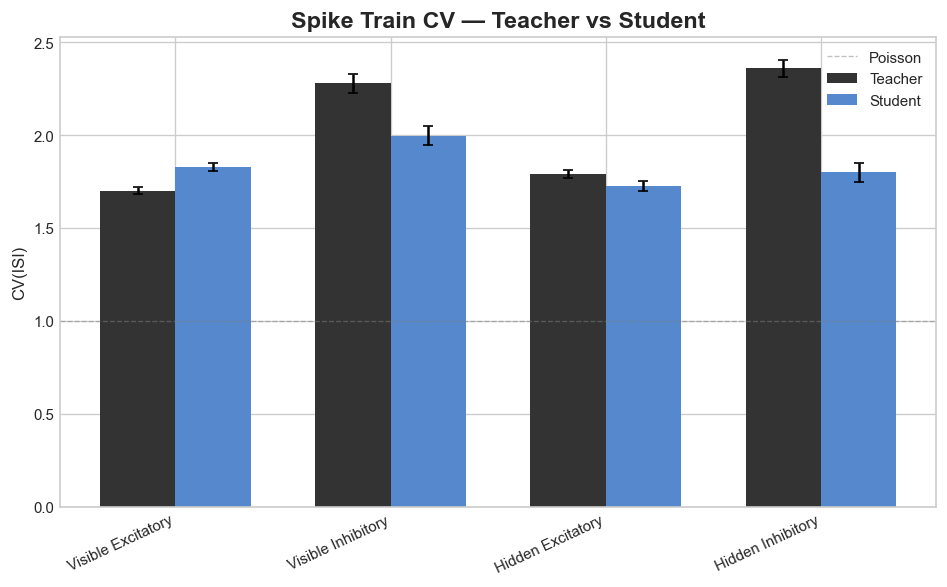

In [21]:
# Spike train CV (ISI): std(ISI) / mean(ISI) per neuron,
# averaged by cell type. CV ~ 1 for Poisson-like (fluctuation-driven),
# CV < 1 for regular (mean-driven) spiking.
from connectome_snns.analysis import compute_cv_by_cell_type

groups_cv = []
for vis_label, t_spikes, s_spikes, ct in [
    ("Visible", data["teacher_visible_spikes"], data["student_visible_spikes"], vis_ct),
    ("Hidden", data["teacher_hidden_spikes"], data["student_hidden_spikes"], hid_ct),
]:
    # compute_cv_by_cell_type expects (batch, time, neurons)
    t_cv = compute_cv_by_cell_type(t_spikes[np.newaxis], ct, dt=dt)
    s_cv = compute_cv_by_cell_type(s_spikes[np.newaxis], ct, dt=dt)

    for type_idx, type_name in enumerate(cell_type_names):
        if type_idx not in t_cv:
            continue
        n_neurons = (ct == type_idx).sum()
        groups_cv.append(
            (
                f"{vis_label} {type_name.title()}",
                {
                    "teacher_cv": t_cv[type_idx]["mean_cv"],
                    "teacher_cv_sem": t_cv[type_idx]["std_cv"] / np.sqrt(n_neurons),
                    "student_cv": s_cv[type_idx]["mean_cv"],
                    "student_cv_sem": s_cv[type_idx]["std_cv"] / np.sqrt(n_neurons),
                },
            )
        )

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(groups_cv))
width = 0.35
labels = [g[0] for g in groups_cv]

t_vals = [g[1]["teacher_cv"] for g in groups_cv]
s_vals = [g[1]["student_cv"] for g in groups_cv]
t_err = [g[1]["teacher_cv_sem"] for g in groups_cv]
s_err = [g[1]["student_cv_sem"] for g in groups_cv]

ax.bar(
    x - width / 2,
    t_vals,
    width,
    yerr=t_err,
    color=TEACHER_COLOR,
    label="Teacher",
    capsize=3,
)
ax.bar(
    x + width / 2,
    s_vals,
    width,
    yerr=s_err,
    color=STUDENT_COLOR,
    label="Student",
    capsize=3,
)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("CV(ISI)")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5, label="Poisson")
ax.set_title(
    "Spike Train CV — Teacher vs Student",
    fontsize=14,
    fontweight="bold",
)
ax.legend()
fig.tight_layout()
plt.show()

### Activity Dashboard

In [22]:
# Run tracked inference for both teacher and student to get
# voltages, currents, and conductances for the activity dashboard.

# Teacher: target SFs to correct perturbation, true FF weights
tracked_teacher = run_two_layer_tracked_inference(
    params_file=RESULTS_DIR / "parameters.toml",
    run_dir=RESULTS_DIR,
    zarr_subpath=str(TEST_ZARR_PATH),
    scaling_factors=sf_teacher_rec,
    scaling_factors_FF=sf_teacher_ff,
    ff_weights=true_ff_log,
    n_burnin_chunks=N_BURNIN_CHUNKS,
    n_analysis_chunks=N_ANALYSIS_CHUNKS,
    device=DEVICE,
    desc="teacher tracked",
)

# Student: learned SFs and FF weights
tracked_student = run_two_layer_tracked_inference(
    params_file=RESULTS_DIR / "parameters.toml",
    run_dir=RESULTS_DIR,
    zarr_subpath=str(TEST_ZARR_PATH),
    scaling_factors=eff_sf_rec,
    scaling_factors_FF=sf_ff_for_inference,
    ff_weights=ff_weights_for_inference,
    n_burnin_chunks=N_BURNIN_CHUNKS,
    n_analysis_chunks=N_ANALYSIS_CHUNKS,
    device=DEVICE,
    desc="student tracked",
)

  Unified synapse registry: 5 types (3 shared between recurrent/feedforward)


teacher tracked (analysis): 100%|██████████| 100/100 [00:29<00:00,  3.44it/s]


  Unified synapse registry: 5 types (3 shared between recurrent/feedforward)


student tracked (analysis): 100%|██████████| 100/100 [00:26<00:00,  3.71it/s]


In [23]:
def _dashboard_args(tracked):
    """Extract hidden layer dashboard arguments from tracked inference result."""
    rec_cfg = tracked["rec_cfg"]
    ff_cfg = tracked["ff_cfg"]
    layer1 = tracked["model"].layer1
    layer1_ct = tracked["layer1_ct"]

    # All data is post-burnin (already stripped)
    hidden_spikes = tracked["hidden_spikes"].astype(np.int32)
    input_spikes = tracked["input_spikes"].astype(np.int32)
    voltages = tracked["hidden_voltages"].astype(np.float32)
    currents_raw = tracked["hidden_currents"].astype(np.float32)
    currents_leak = tracked["hidden_currents_leak"].astype(np.float32)
    conductances_raw = tracked["hidden_conductances"].astype(np.float32)

    # Split unified currents/conductances using model's synapse mappings.
    # Recurrent IDs (includes rerouted visible-teacher contributions).
    # FF-unique IDs = mitral-only (original FF synapse IDs < n_ff_syn).
    rec_ids = sorted(set(layer1.rec_synapse_to_unified.values()))
    n_ff_syn = len(ff_cfg.get_synapse_params())
    ff_ids = sorted(
        set(uid for sid, uid in layer1.ff_synapse_to_unified.items() if sid < n_ff_syn)
    )

    return dict(
        output_spikes=hidden_spikes,
        input_spikes=input_spikes,
        cell_type_indices=layer1_ct,
        cell_type_names=rec_cfg.cell_types.names,
        dt=tracked["dt"],
        voltages=voltages,
        neuron_types=layer1_ct,
        neuron_params=rec_cfg.get_neuron_params_for_plotting(),
        recurrent_currents=currents_raw[..., rec_ids],
        feedforward_currents=currents_raw[..., ff_ids],
        leak_currents=currents_leak,
        recurrent_conductances=conductances_raw[..., rec_ids],
        feedforward_conductances=conductances_raw[..., ff_ids],
        input_cell_type_names=ff_cfg.cell_types.names,
        recurrent_synapse_names=rec_cfg.get_synapse_names(),
        feedforward_synapse_names=ff_cfg.get_synapse_names(),
    )

Selected neuron index: 21


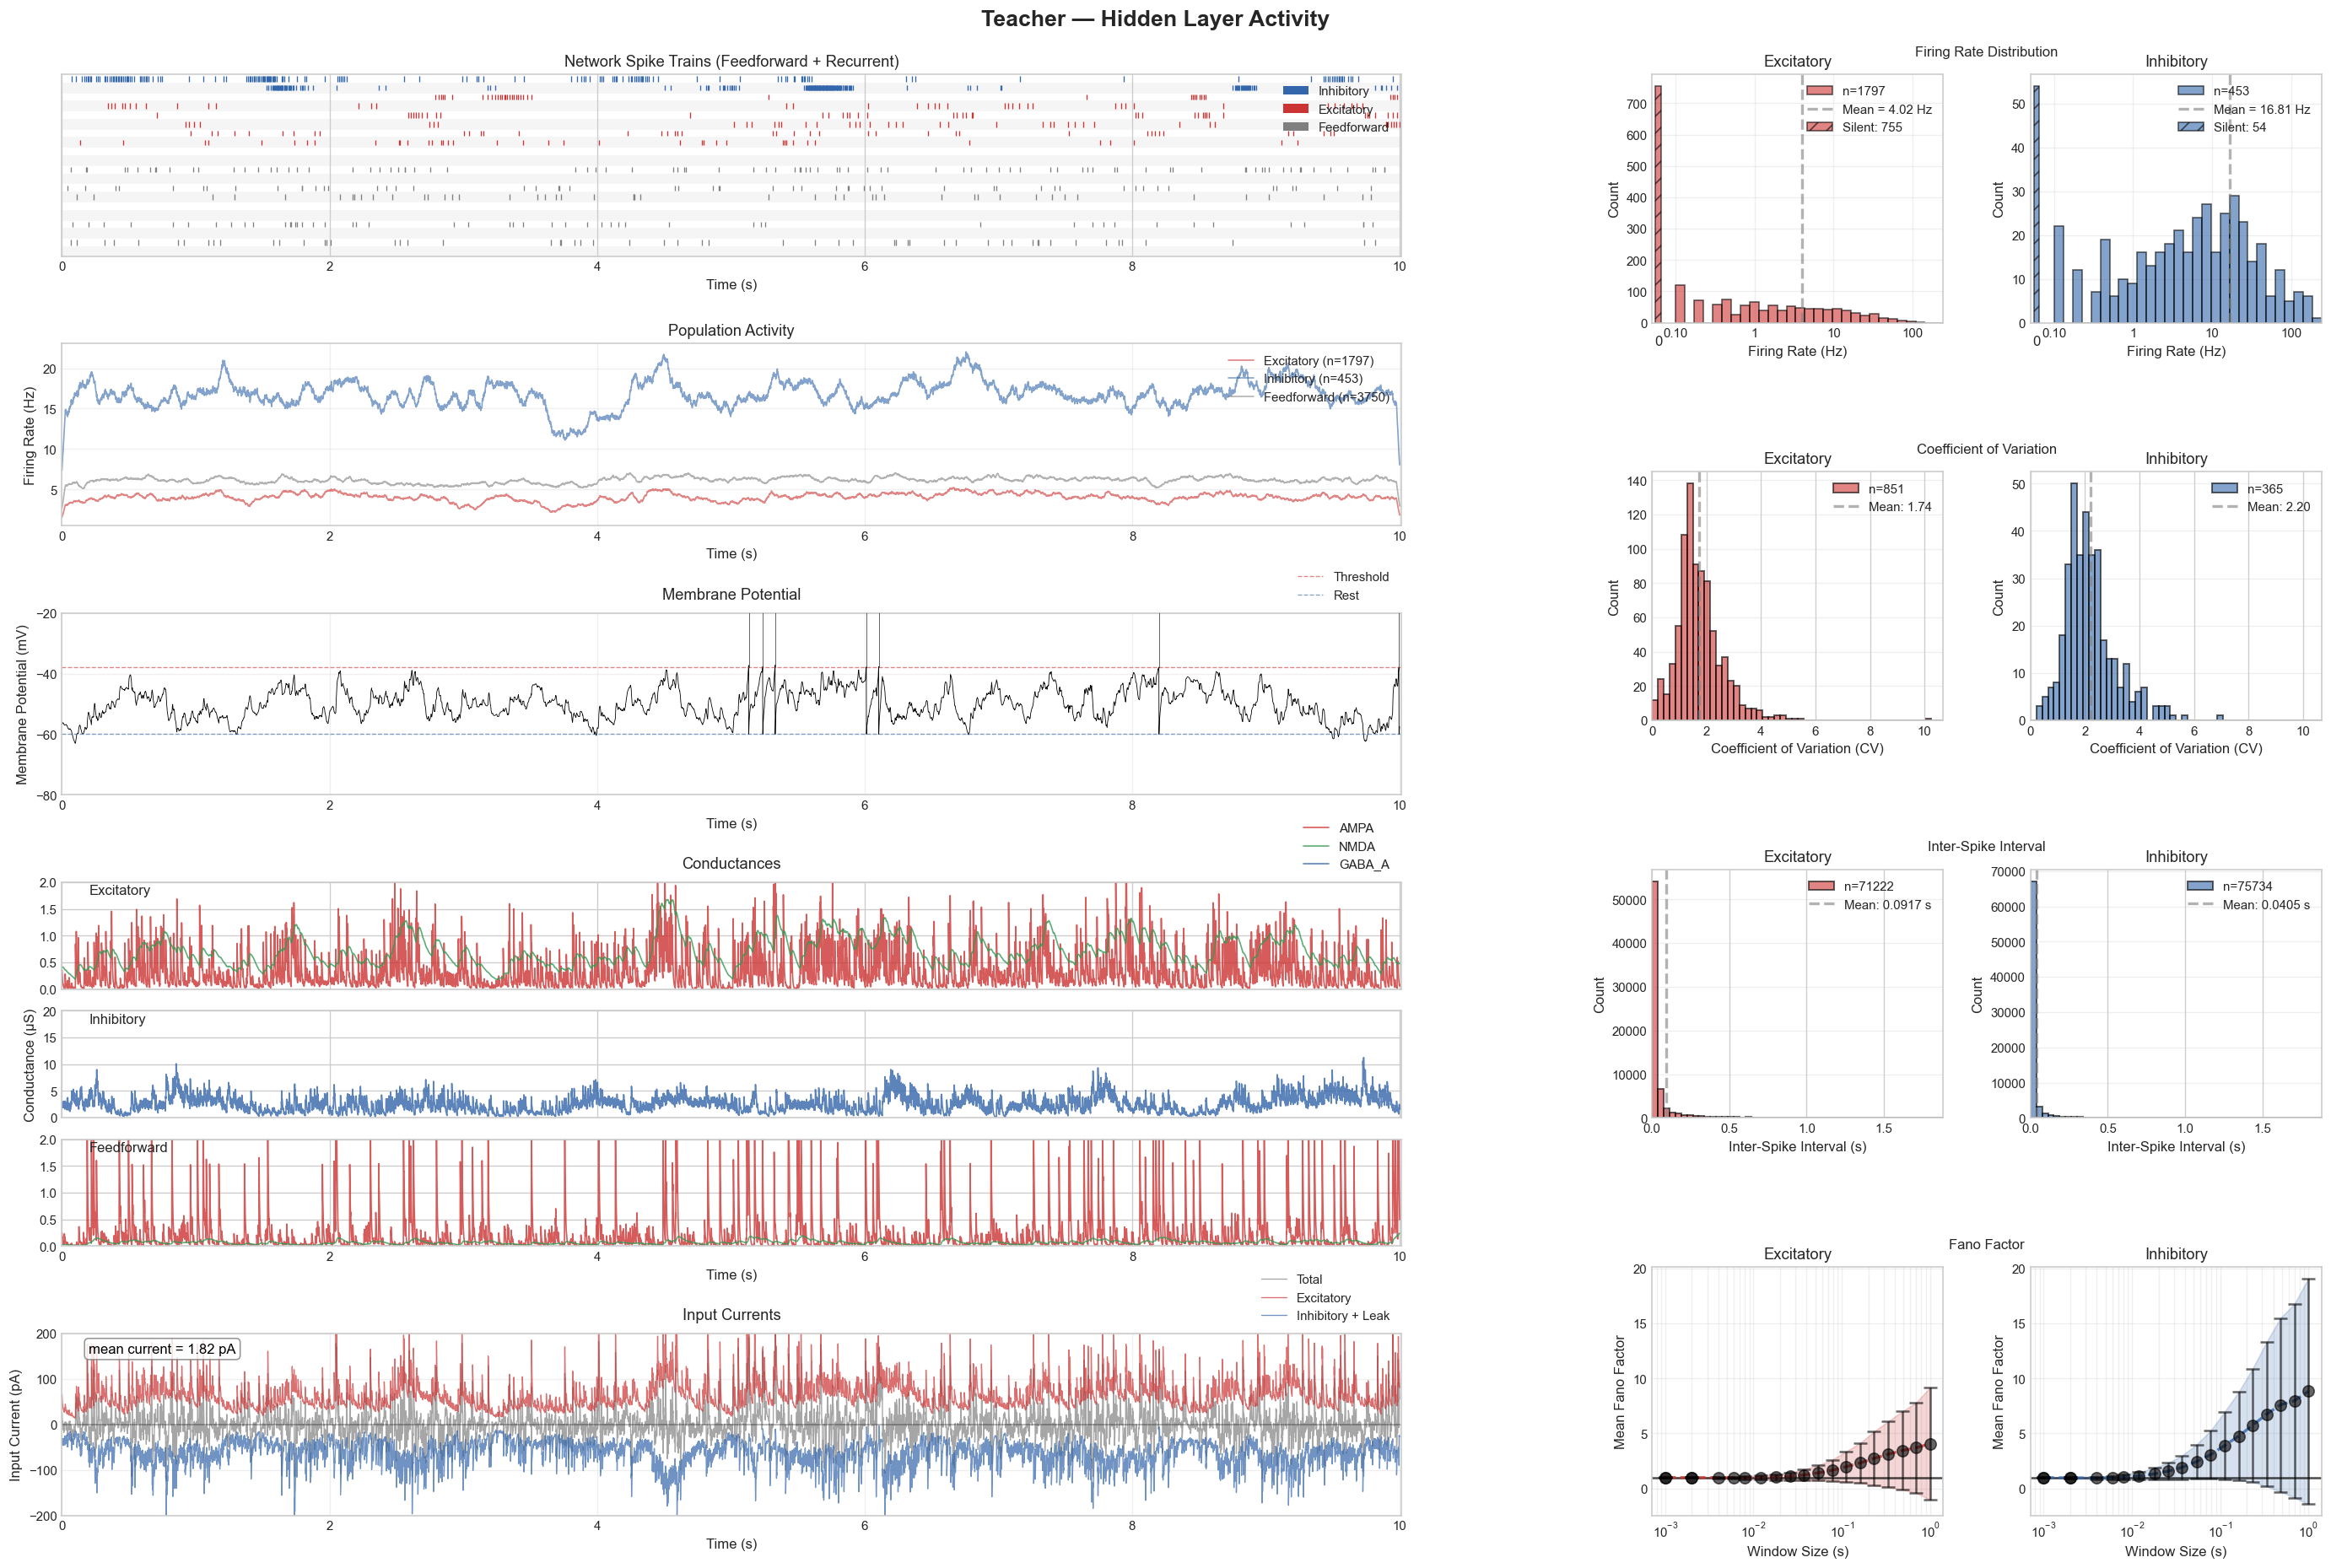

Selected neuron index: 181


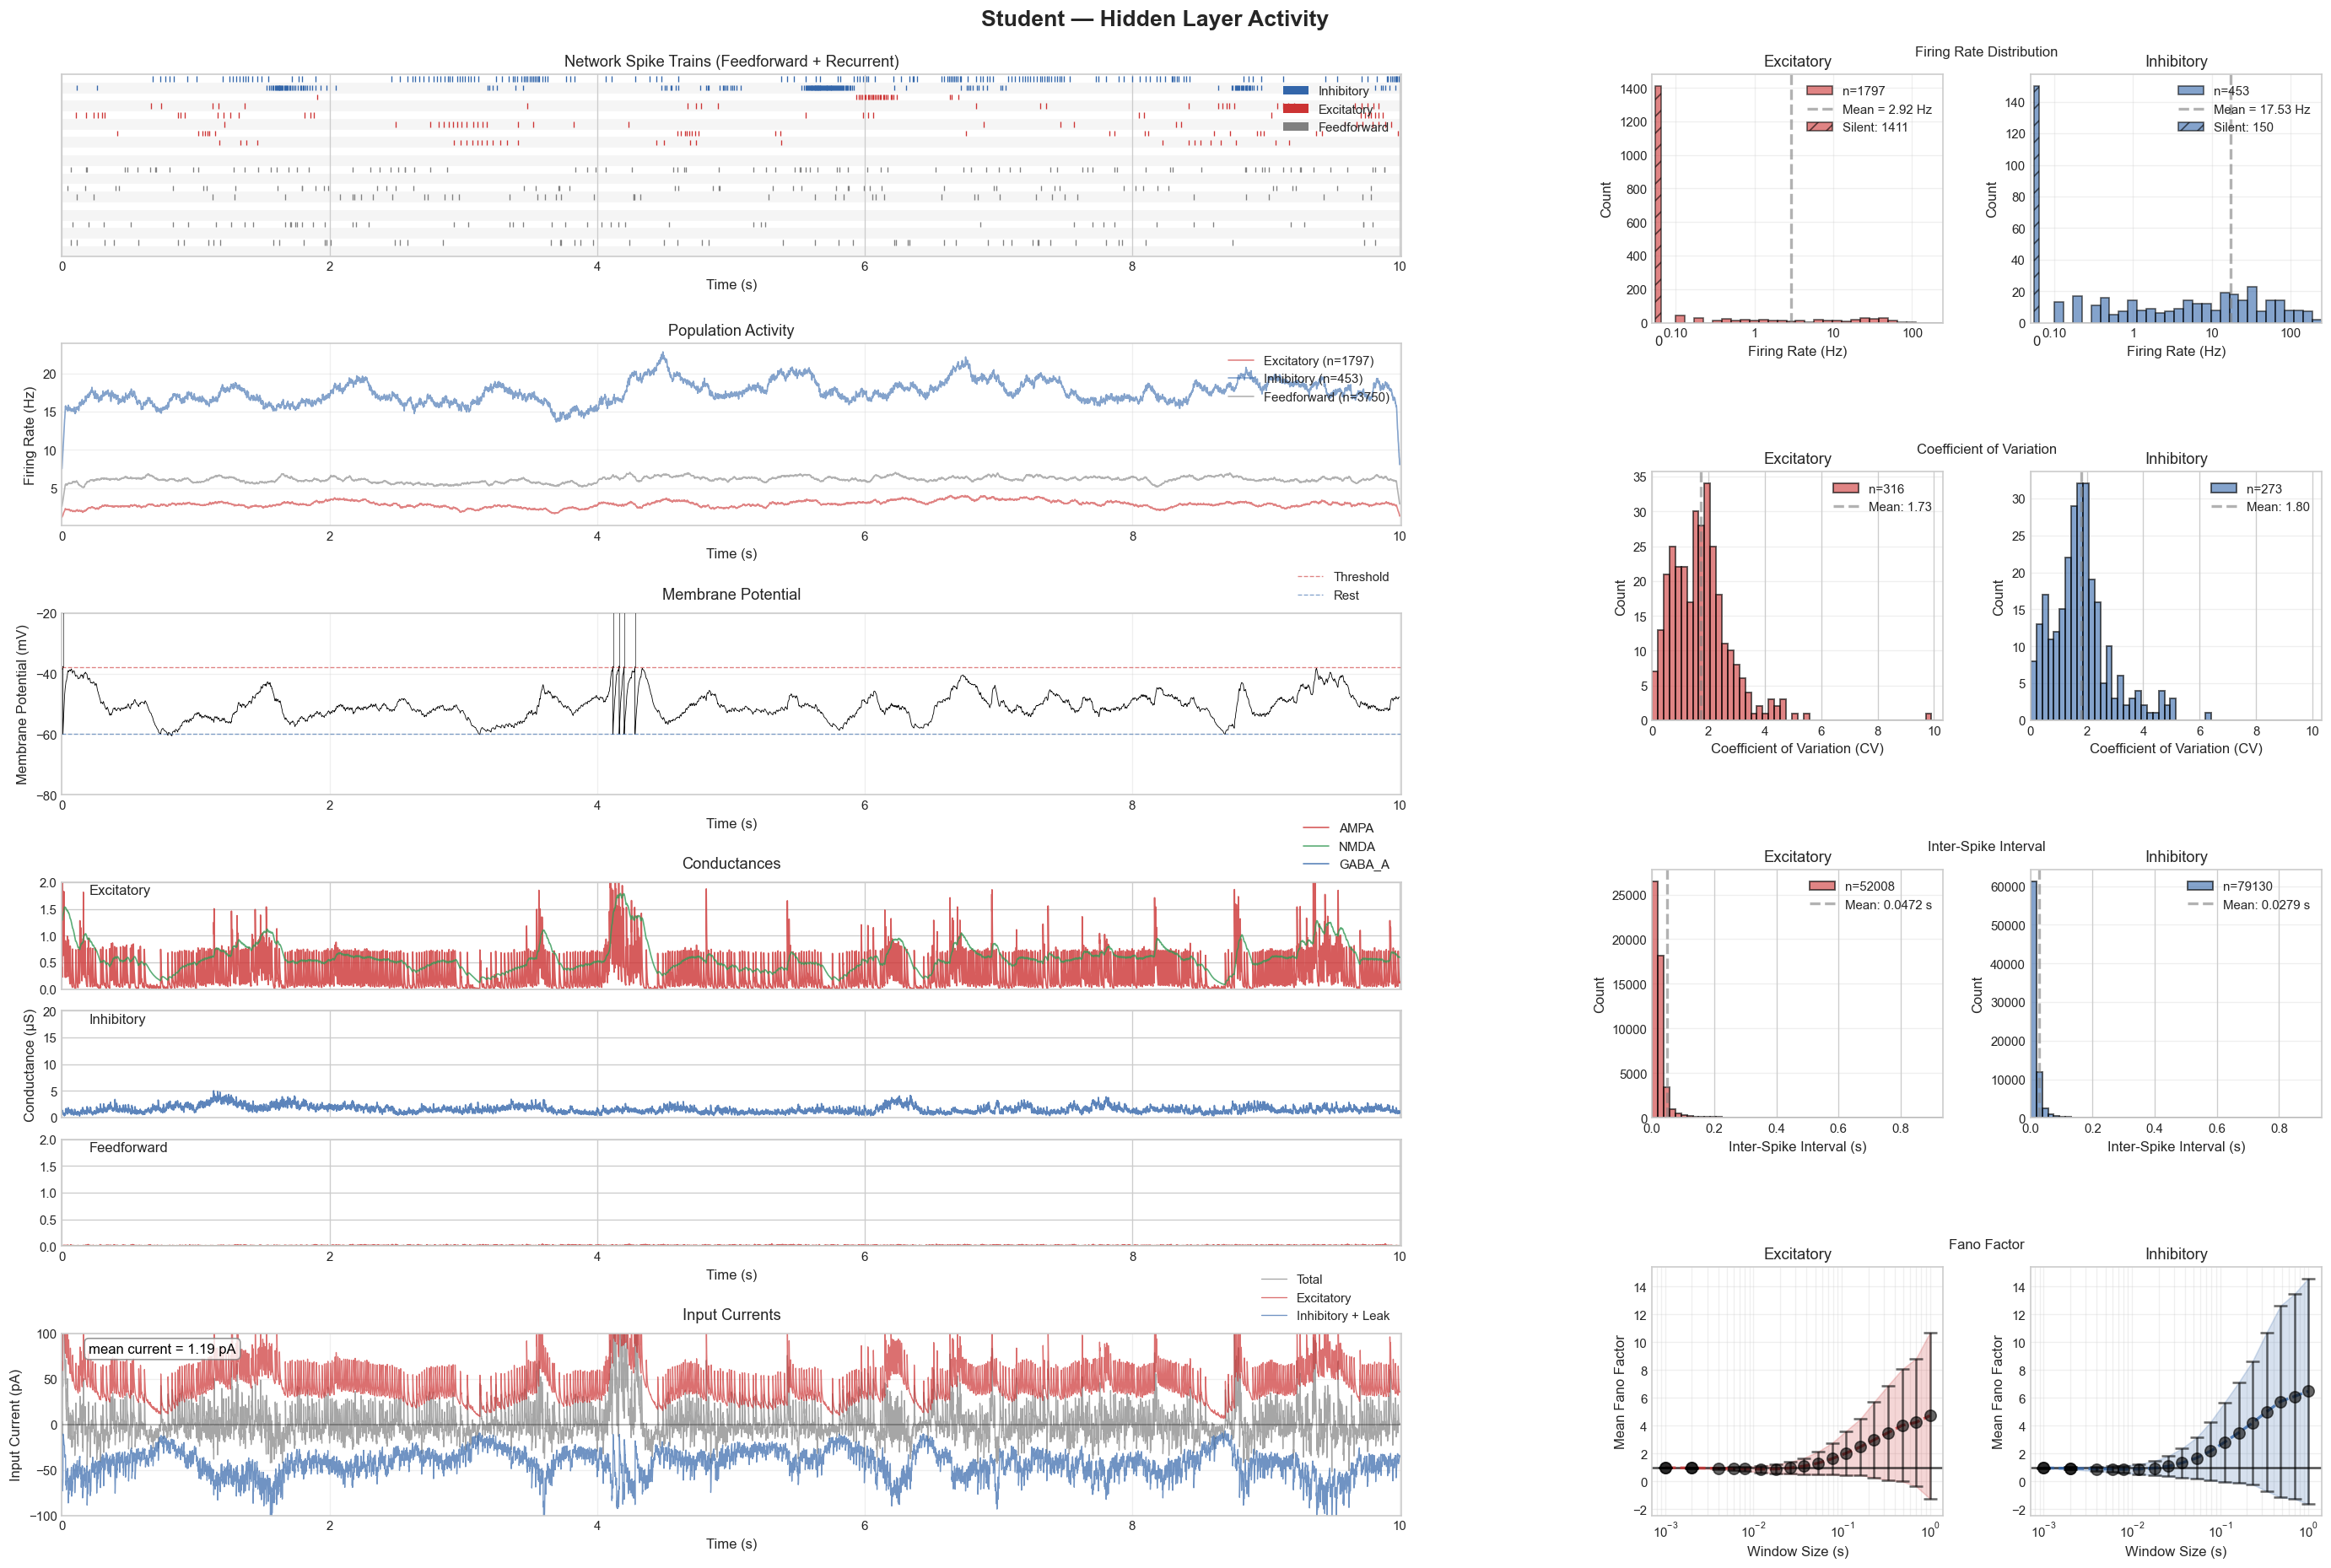

In [24]:
# Teacher activity dashboard (hidden neurons)
teacher_args = _dashboard_args(tracked_teacher)
teacher_fig = create_activity_dashboard(**teacher_args)
teacher_fig.suptitle(
    "Teacher — Hidden Layer Activity", fontsize=16, fontweight="bold", y=0.98
)
plt.show()

# Student activity dashboard (hidden neurons)
student_args = _dashboard_args(tracked_student)
student_fig = create_activity_dashboard(**student_args)
student_fig.suptitle(
    "Student — Hidden Layer Activity", fontsize=16, fontweight="bold", y=0.98
)
plt.show()

### Summary Statistics

In [25]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")


def compute_fluctuations(spikes, dt, bin_ms=250):
    """Per-neuron std of binned firing rates (temporal variability)."""
    bin_size = int(bin_ms / dt)
    n_time, n_neurons = spikes.shape
    n_bins = n_time // bin_size
    trimmed = spikes[: n_bins * bin_size, :]
    binned = trimmed.reshape(n_bins, bin_size, n_neurons).sum(axis=1) / (
        bin_ms / 1000.0
    )
    return binned.std(axis=0)


t_vis_fluct = compute_fluctuations(data["teacher_visible_spikes"], dt)
s_vis_fluct = compute_fluctuations(data["student_visible_spikes"], dt)
t_hid_fluct = compute_fluctuations(data["teacher_hidden_spikes"], dt)
s_hid_fluct = compute_fluctuations(data["student_hidden_spikes"], dt)

rows = []
for visibility, t_rates, s_rates, t_fluct, s_fluct, ct in [
    ("Visible", teacher_vis_rates, student_vis_rates, t_vis_fluct, s_vis_fluct, vis_ct),
    ("Hidden", teacher_hid_rates, student_hid_rates, t_hid_fluct, s_hid_fluct, hid_ct),
]:
    for type_idx, type_name in enumerate(cell_type_names):
        mask = ct == type_idx
        if mask.sum() == 0:
            continue
        rows.append(
            {
                "Group": f"{visibility} {type_name.title()}",
                "N": int(mask.sum()),
                "R2 Rate": r_squared(t_rates[mask], s_rates[mask]),
                "R2 Fluct": r_squared(t_fluct[mask], s_fluct[mask]),
                "Teacher Rate (Hz)": t_rates[mask].mean(),
                "Student Rate (Hz)": s_rates[mask].mean(),
            }
        )

summary = pd.DataFrame(rows).set_index("Group")

summary.style.format(
    {
        "R2 Rate": "{:.3f}",
        "R2 Fluct": "{:.3f}",
        "Teacher Rate (Hz)": "{:.1f}",
        "Student Rate (Hz)": "{:.1f}",
    }
)

,N,R2 Rate,R2 Fluct,Teacher Rate (Hz),Student Rate (Hz)
Group,,,,,
Visible Excitatory,1808,0.892,0.655,3.6,2.4
Visible Inhibitory,442,0.967,0.672,18.6,16.2
Hidden Excitatory,1797,0.224,0.380,4.1,2.9
Hidden Inhibitory,453,0.146,0.278,18.0,17.5
